In [1]:
#forces us to reload the libraries each time we do a function call,
#so I can update things in real time
%load_ext autoreload
%autoreload 2
#import path libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from utils import psf
from utils import plotting
from utils import zernike

In [2]:
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300

In [3]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05
L_ffp = 0.0065             # FFP size [mm]
grid_ffp = 64
grid_bfp = 64

In [4]:
microscope = psf.Microscope(N_order = N_order,
                            lambd = lambd,
                            n = n,
                            num_apt = num_apt,
                            f = f,
                            mag = mag,
                            w_0 = w_0,
                            L_bfp = L_bfp,
                            grid_bfp = grid_bfp)


aberration = zernike.Aberration(modes = np.array([[0, 4]]), 
                                strengths = np.array([-0.15]))

grid = psf.Centered_Square_Grid(L_ffp = L_ffp,
                                grid_ffp = grid_ffp,
                                z_level = 0)

mask = psf.Bead_Image(grid = grid,
                            xs = [0.0],
                            ys = [0.0],
                            bead_sizes = [0.0001])

xs, ys = grid.get_xy()


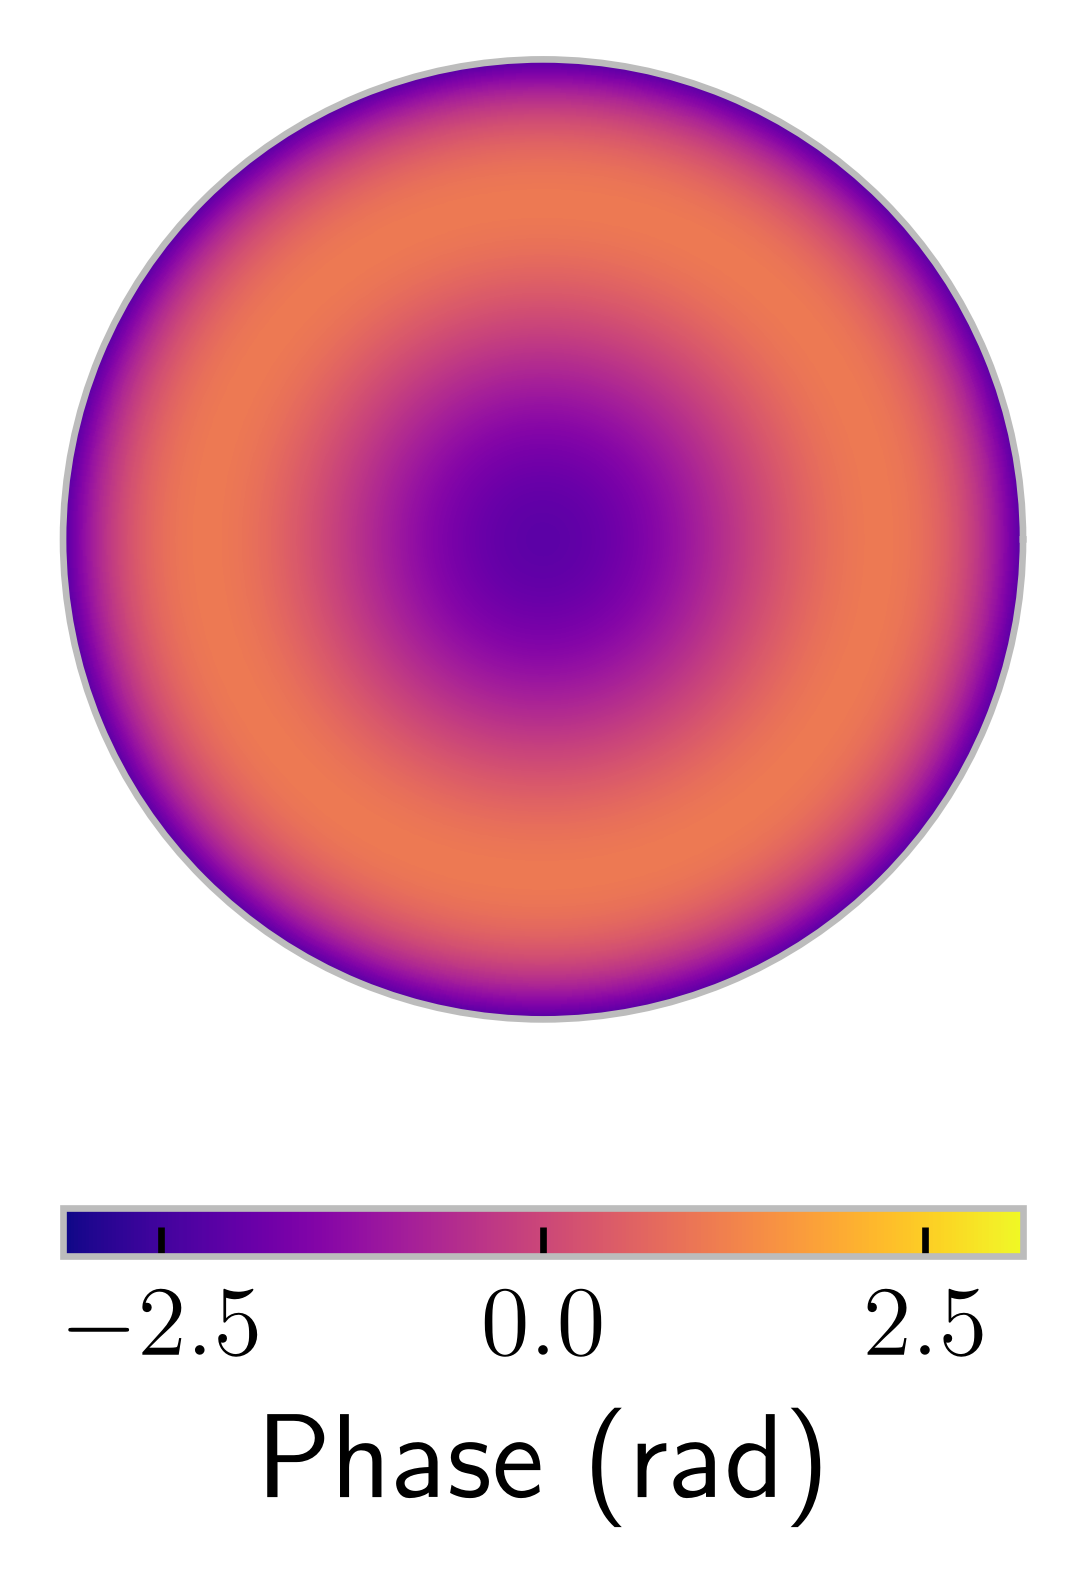

(<Figure size 1200x1800 with 2 Axes>, <PolarAxes: >)

In [5]:
plotting.zernike_plot(aberration.construct_map(microscope.alpha), microscope.alpha)

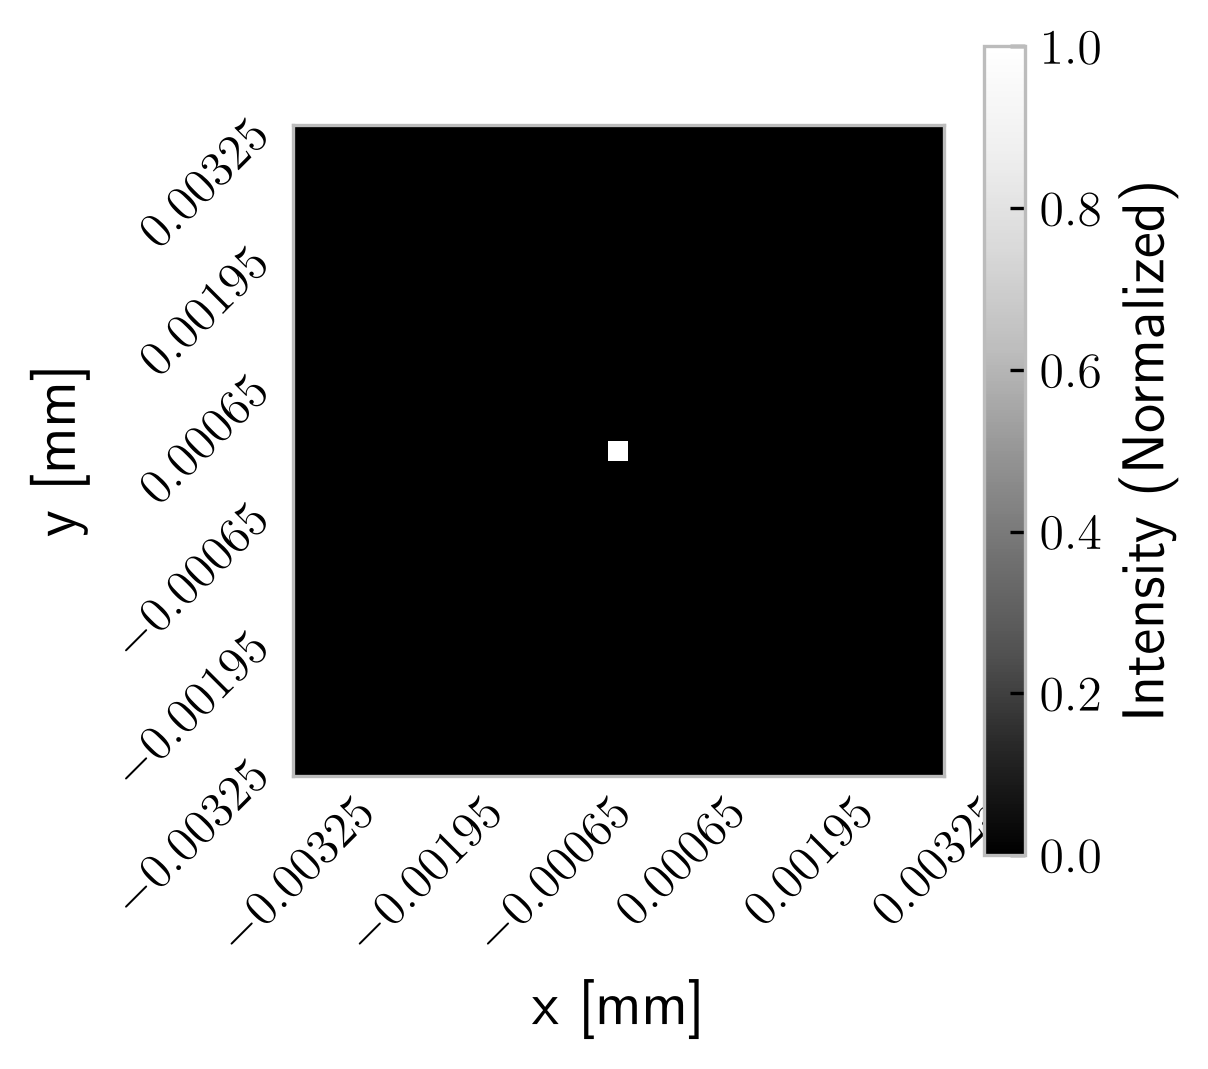

(<Figure size 1050x1050 with 2 Axes>, <Axes: xlabel='x [mm]', ylabel='y [mm]'>)

In [6]:
plotting.plot_intensity(xs, ys, mask.image_mask)

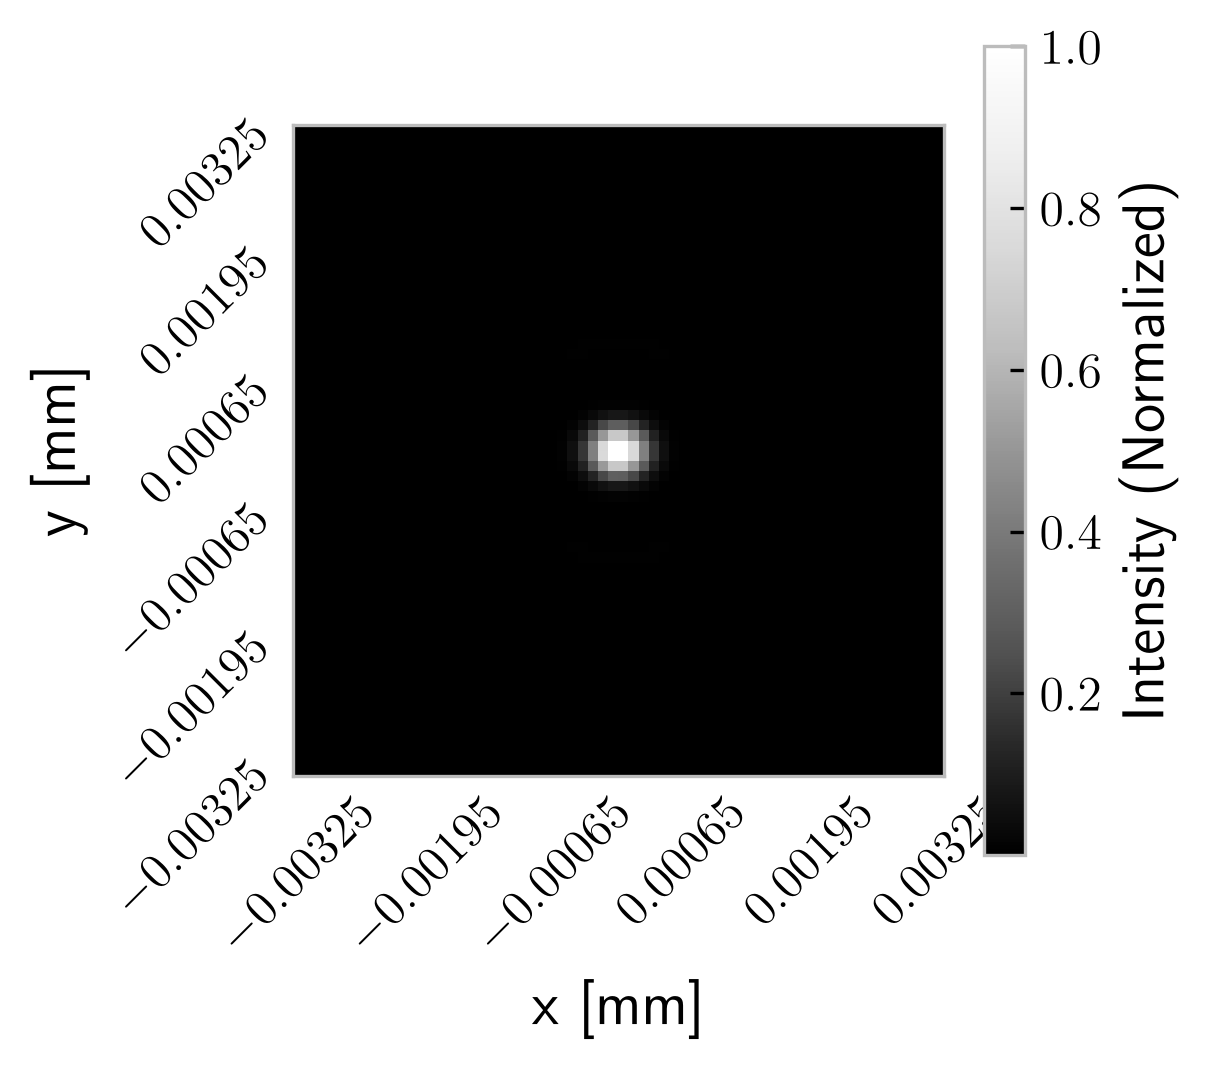

(<Figure size 1050x1050 with 2 Axes>, <Axes: xlabel='x [mm]', ylabel='y [mm]'>)

In [7]:
xs, ys, aberrated_img = microscope.compute_image(image = mask,
                         aberration = aberration,
                         mode = "vector",
                         norm = False)

plotting.plot_intensity(xs, ys, aberrated_img)

In [8]:
z_sample_levels = np.arange(-0.002, 0.002, 0.00010)

In [12]:

mask_3D = psf.bead_img_3D(grid = grid,
                          z_levels = z_sample_levels,
                          xs = [0],
                          ys = [0],
                          zs = [0],
                          bead_sizes = [0.001])

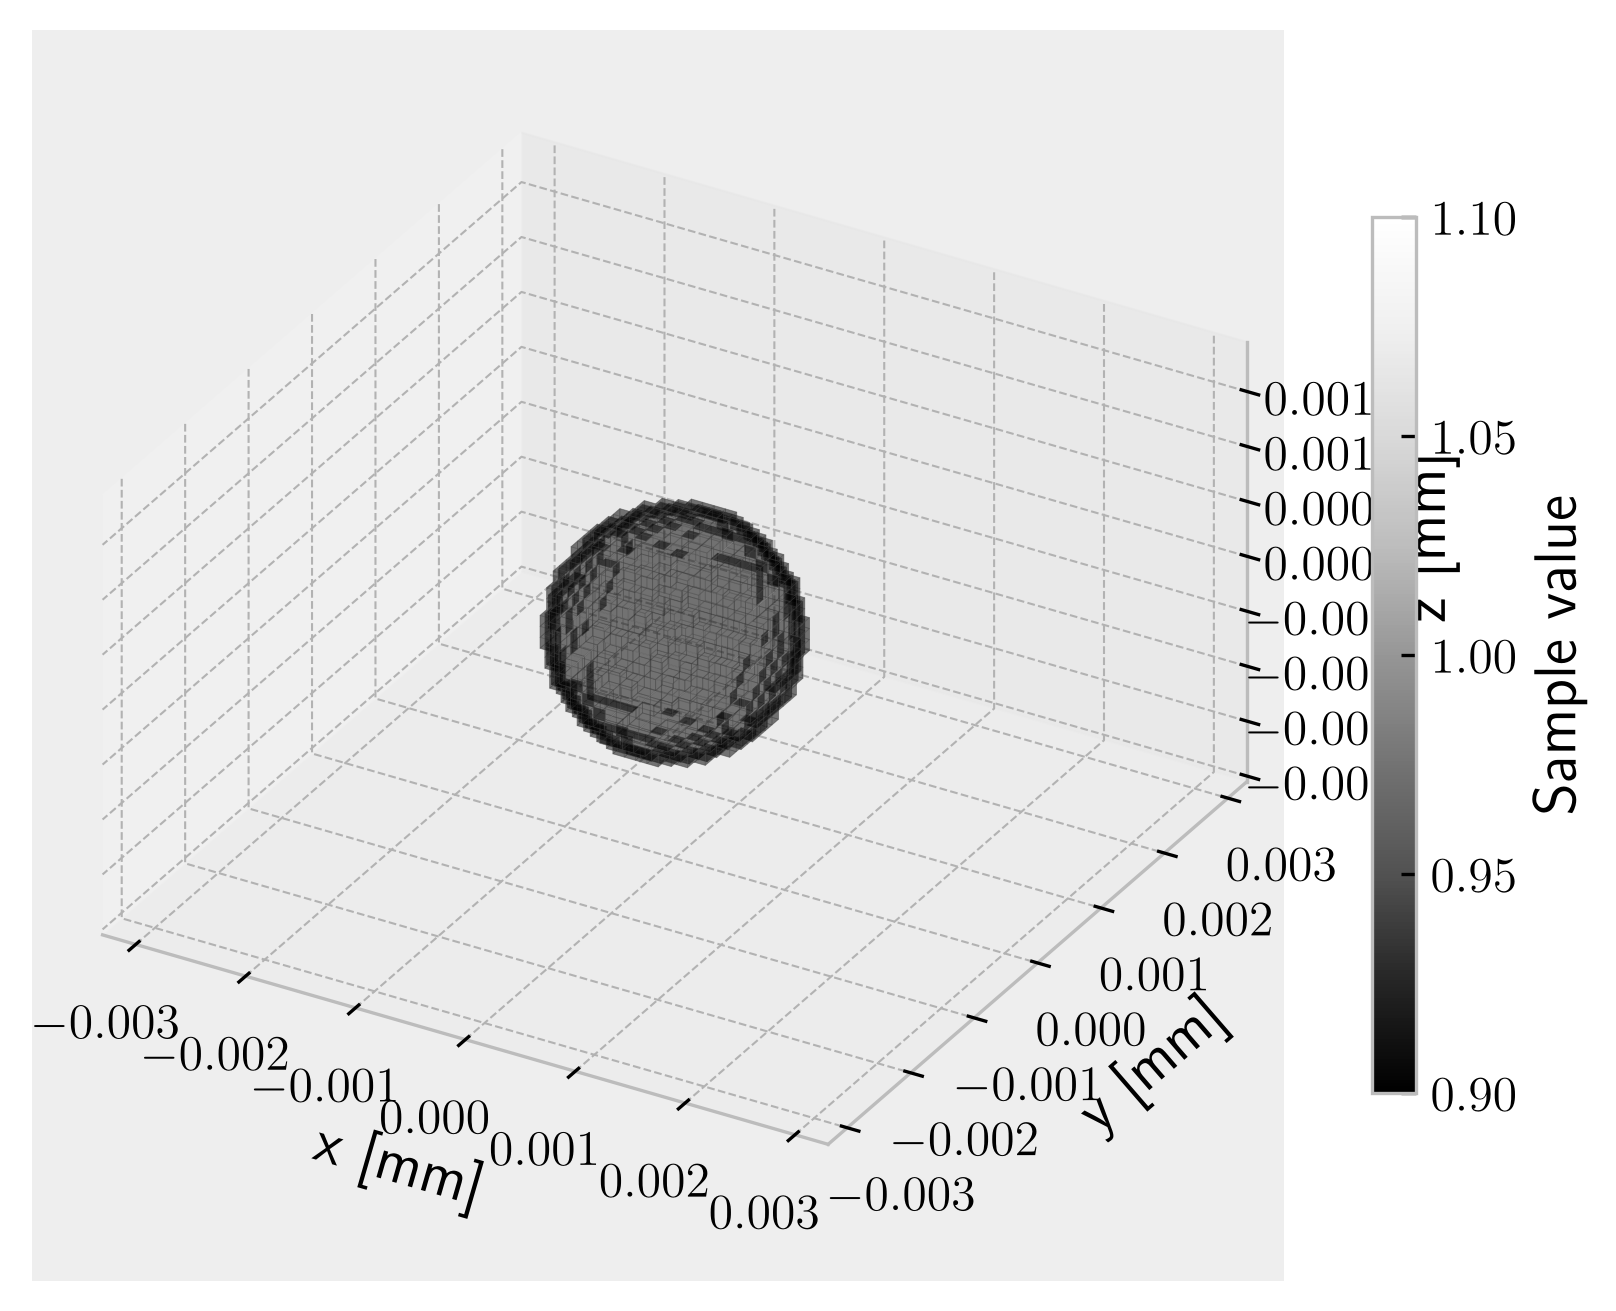

In [13]:
fig, ax = plotting.plot_sample_3D(mask_3D)

In [14]:
eps = 0.000001
z_image_levels = np.arange(-0.002, 0.002, 0.0005)

# Acquire every focal plane with three known spherical diversities (waves).
focal_positions = z_image_levels.copy()
diversity_strengths = [0.0, -0.05, 0.05]
z_image_levels = np.tile(focal_positions, len(diversity_strengths))
diversities = [
    zernike.Aberration([[0, 4]], [strength])
    for strength in diversity_strengths
    for _ in focal_positions
]


In [15]:
z_image_levels

array([-0.002 , -0.0015, -0.001 , -0.0005,  0.    ,  0.0005,  0.001 ,
        0.0015, -0.002 , -0.0015, -0.001 , -0.0005,  0.    ,  0.0005,
        0.001 ,  0.0015, -0.002 , -0.0015, -0.001 , -0.0005,  0.    ,
        0.0005,  0.001 ,  0.0015])

In [16]:
x, y, z, I = microscope.compute_image_3D(image = mask_3D,
                            aberration = aberration,
                            focal_z_levels = z_image_levels,
                            diversities = diversities)

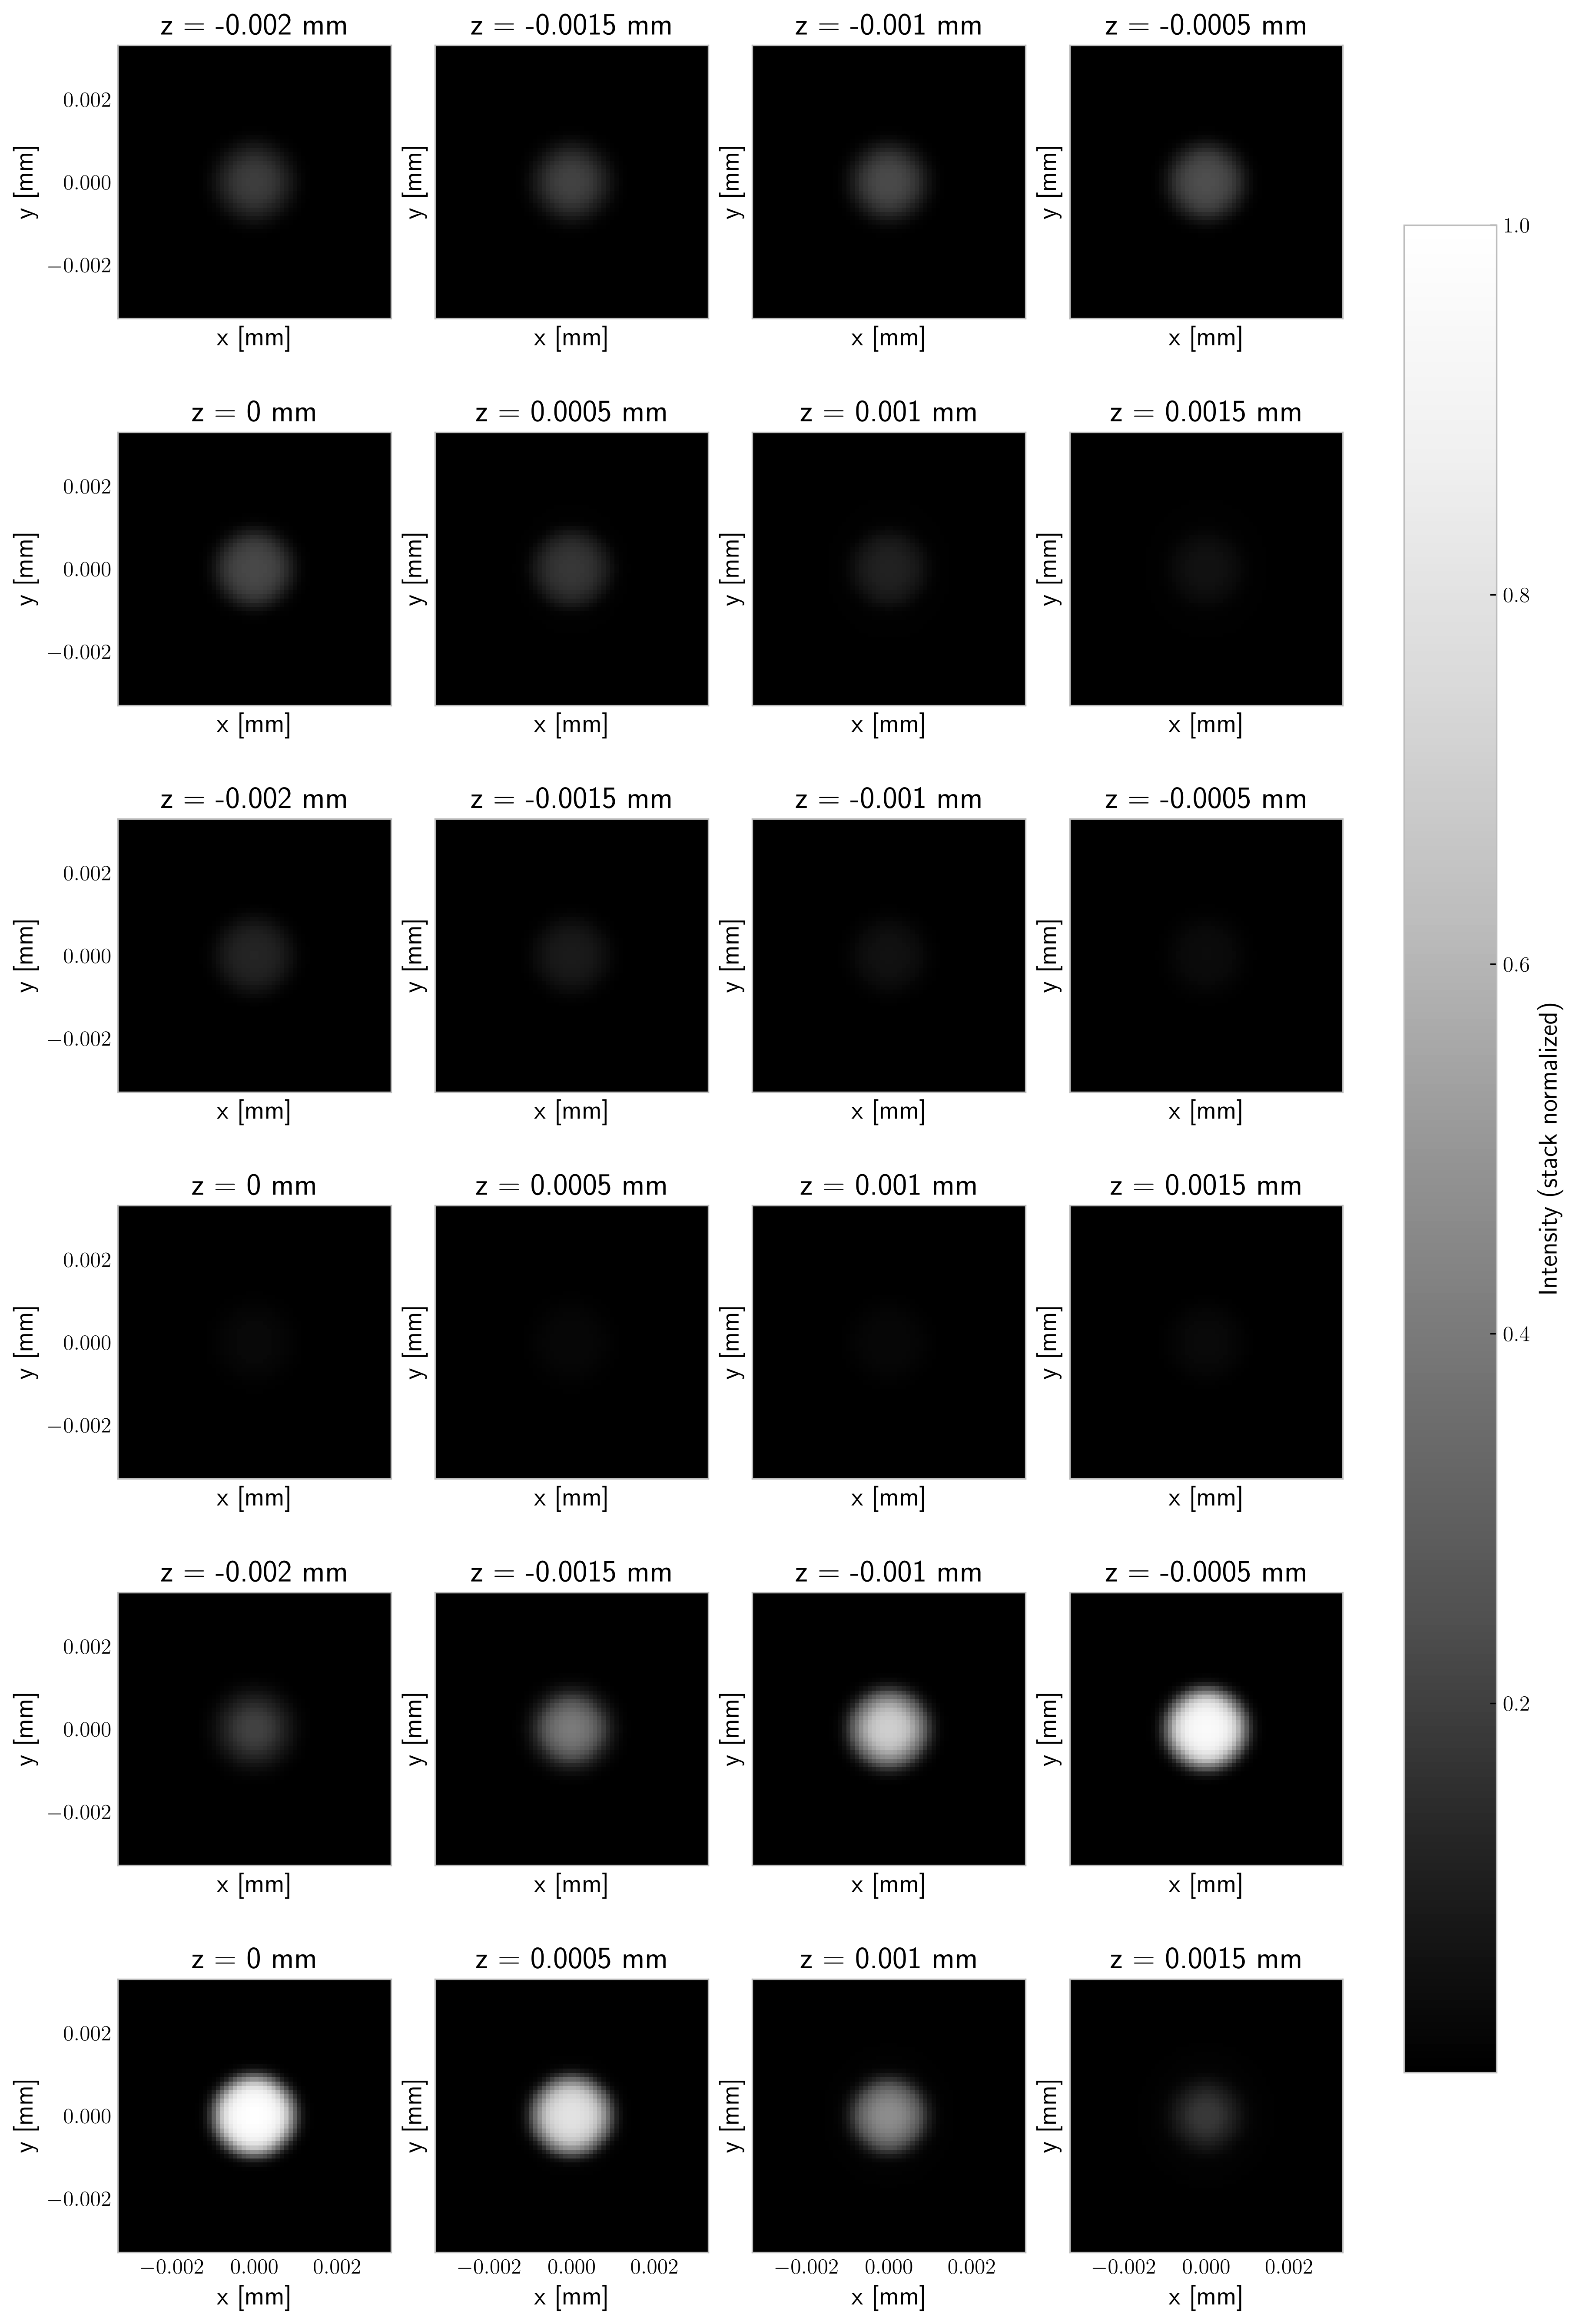

In [17]:
fig, axs = plotting.plot_image_stack(x, y, z, I, ncols=4)

In [18]:
from optimization import reconstruction

In [19]:
reconstructed_img = reconstruction.estimate_sample_3D(microscope = microscope,
                                  grid = grid,
                                  images = I,
                                  focal_z_levels = z_image_levels,
                                  diversities = diversities,
                                  sample_z_levels = z_sample_levels,
                                  aberration = aberration,
                                  rho = 1e48)

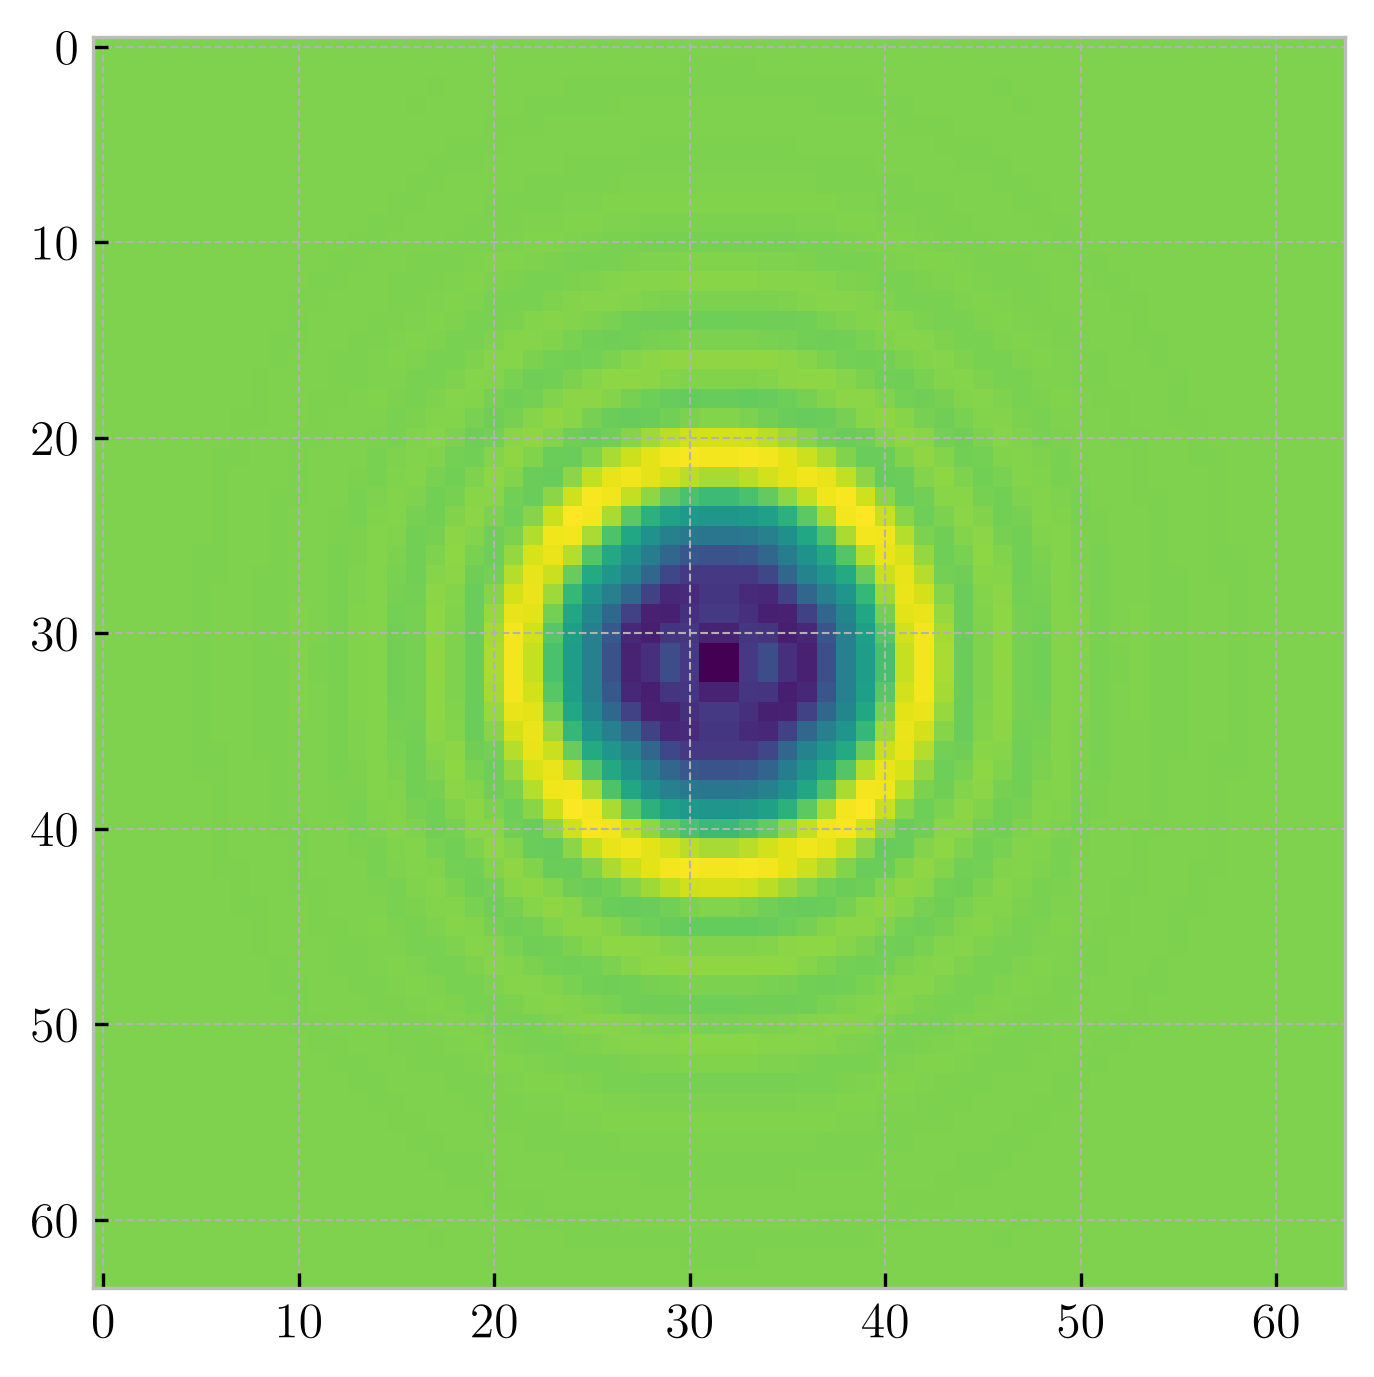

In [51]:
plt.imshow(reconstructed_img.image_mask[35])

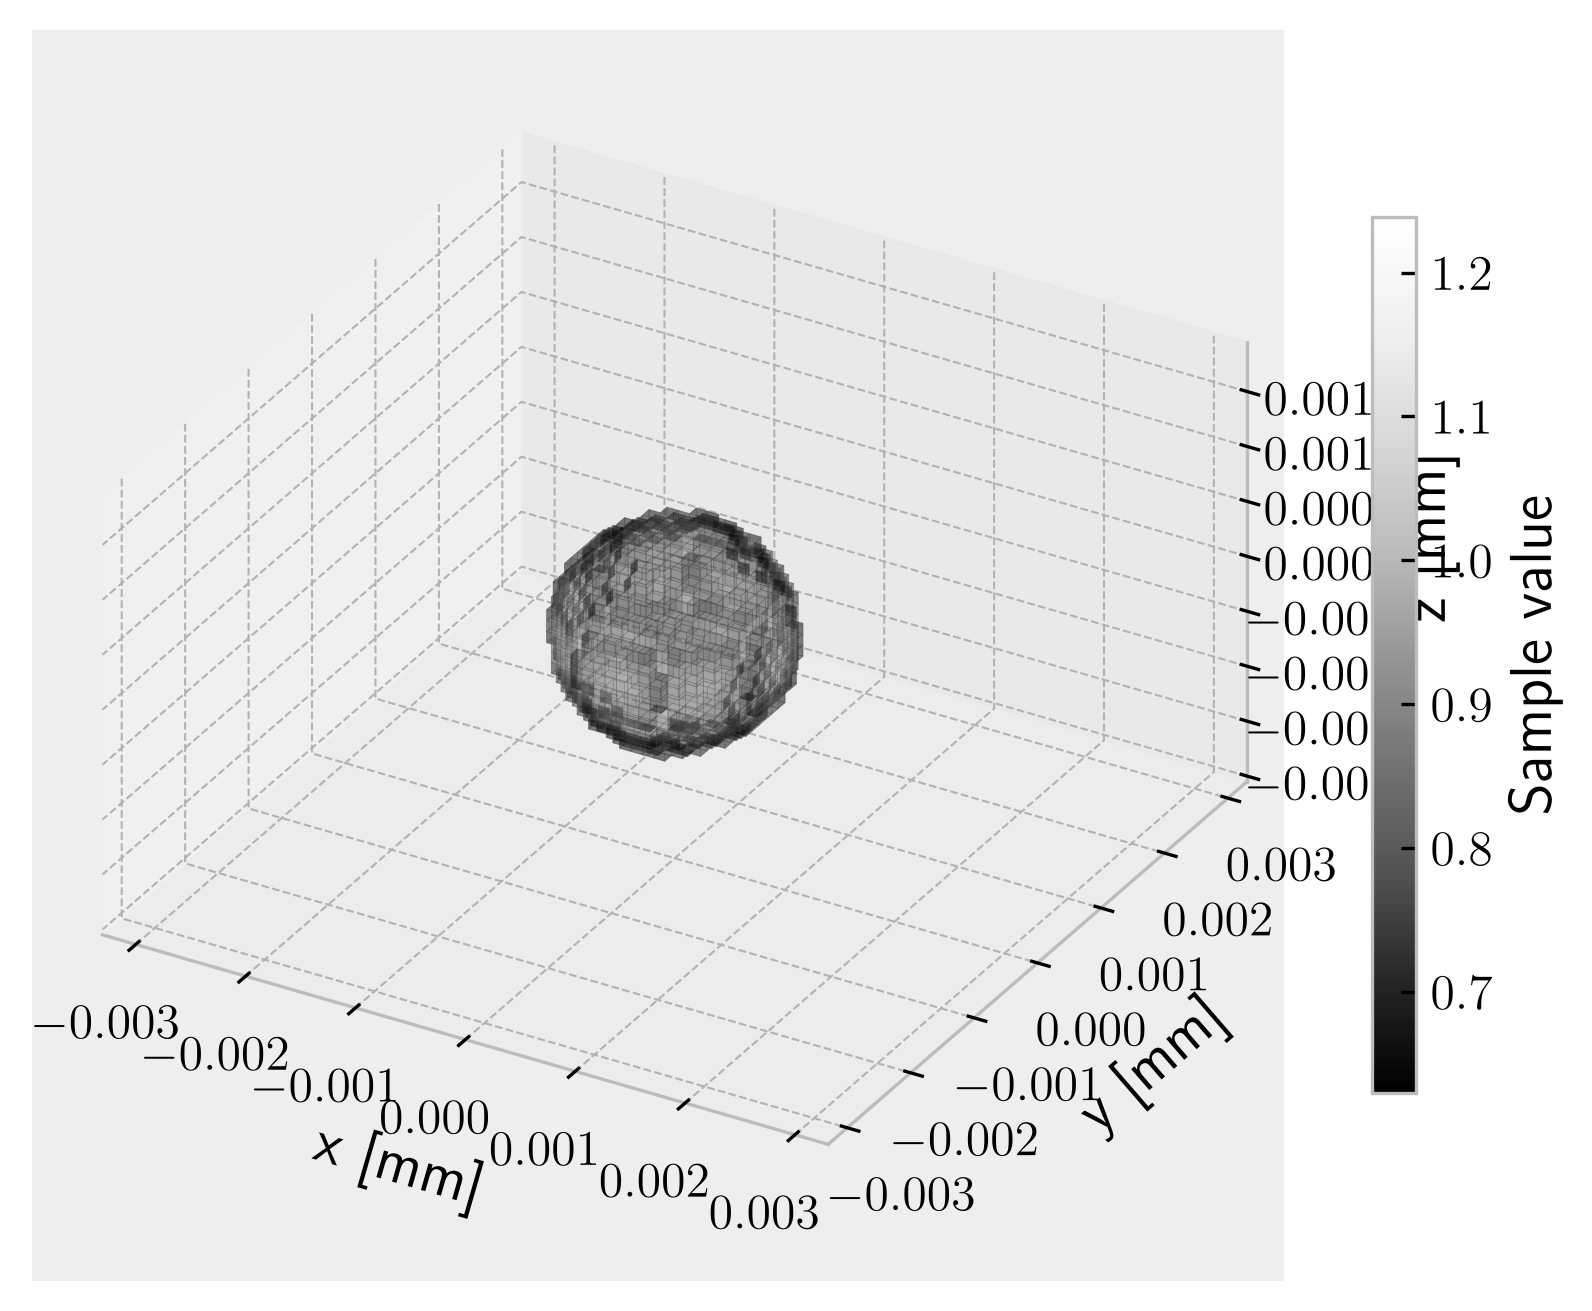

In [20]:
fig, ax = plotting.plot_sample_3D(reconstructed_img, np.percentile(reconstructed_img.image_mask,98))

In [21]:
naive_reconstructed_img = reconstruction.estimate_sample_3D(microscope = microscope,
                                  grid = grid,
                                  images = I,
                                  focal_z_levels = z_image_levels,
                                  diversities = diversities,
                                  sample_z_levels = z_sample_levels,
                                  aberration = zernike.EmptyAberration(),
                                  rho = 1e48)

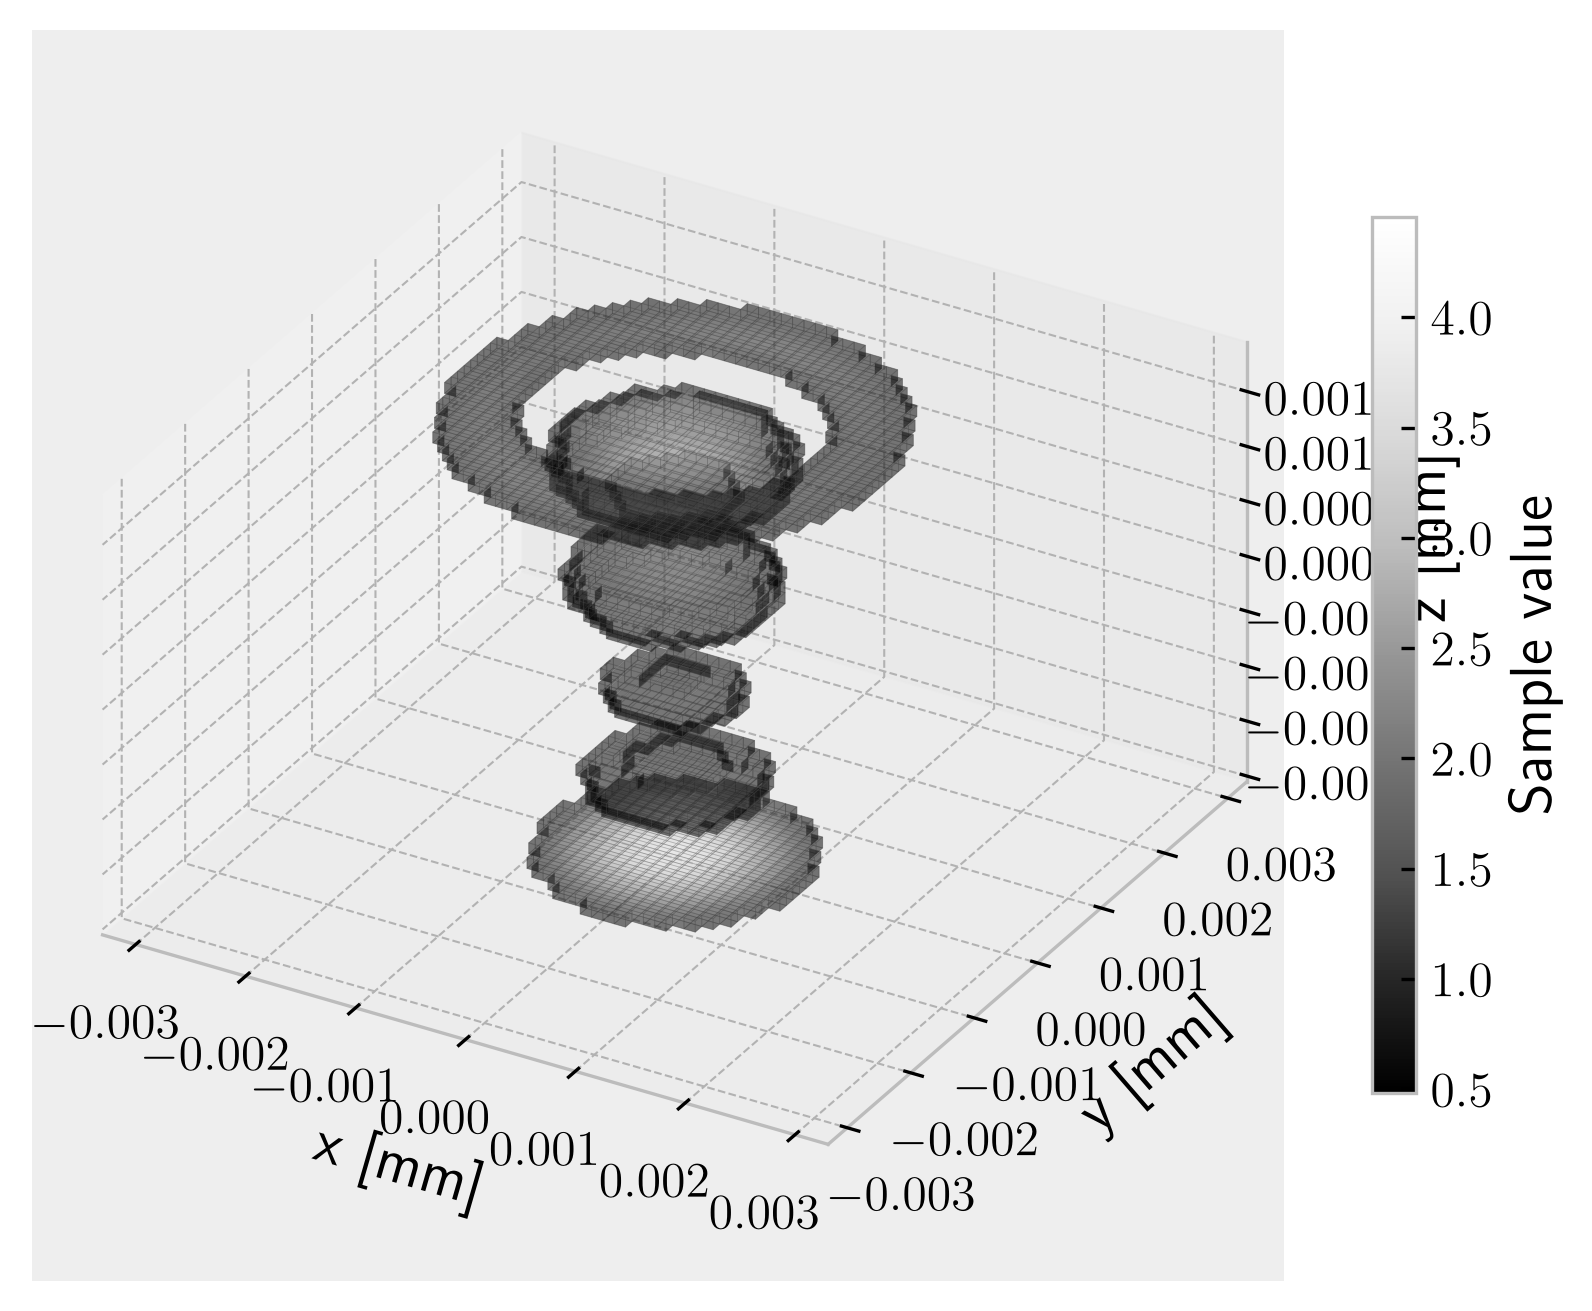

In [22]:
fig, ax = plotting.plot_sample_3D(naive_reconstructed_img, np.percentile(naive_reconstructed_img.image_mask,98))

In [55]:
strengths = np.arange(-0.20, 0.20, 0.01)
losses = np.zeros(len(strengths))
for i, strength in enumerate(strengths):
    losses[i] = reconstruction.evaluate_loss_3D(microscope = microscope, 
                                    grid = grid,
                                    images = I,
                                    focal_z_levels = z_image_levels,
                                    diversities = diversities,
                                    sample_z_levels = z_sample_levels,
                                    aberration = zernike.Aberration([[0,4]], [strength]),
                                    rho = 1e48)
    print(f"{strength}, {losses[i]}")


-0.2, 2.7823045727328787e+58
-0.19, 1.4065911808941038e+58
-0.18, 6.527300270517255e+57
-0.16999999999999998, 2.5537166473391374e+57
-0.15999999999999998, 6.388159211242907e+56
-0.14999999999999997, 5.704619932827567e+55
-0.13999999999999996, 5.557393128625349e+56
-0.12999999999999995, 2.2248288135011836e+57
-0.11999999999999994, 5.425814538513739e+57
-0.10999999999999993, 1.0725794922517627e+58
-0.09999999999999992, 1.8831565300110683e+58
-0.08999999999999991, 3.052728743384387e+58
-0.0799999999999999, 4.6609386914287633e+58
-0.0699999999999999, 6.7808731342578e+58
-0.05999999999999989, 9.469520801724165e+58
-0.04999999999999988, 1.2756715453840615e+59
-0.03999999999999987, 1.663360450214972e+59
-0.02999999999999986, 2.1042715221137187e+59
-0.01999999999999985, 2.58727782686763e+59
-0.009999999999999842, 3.0961807823366195e+59
1.6653345369377348e-16, 3.611062103874293e+59
0.010000000000000175, 4.110591113780631e+59
0.020000000000000184, 4.574831273173131e+59
0.030000000000000193, 4.98

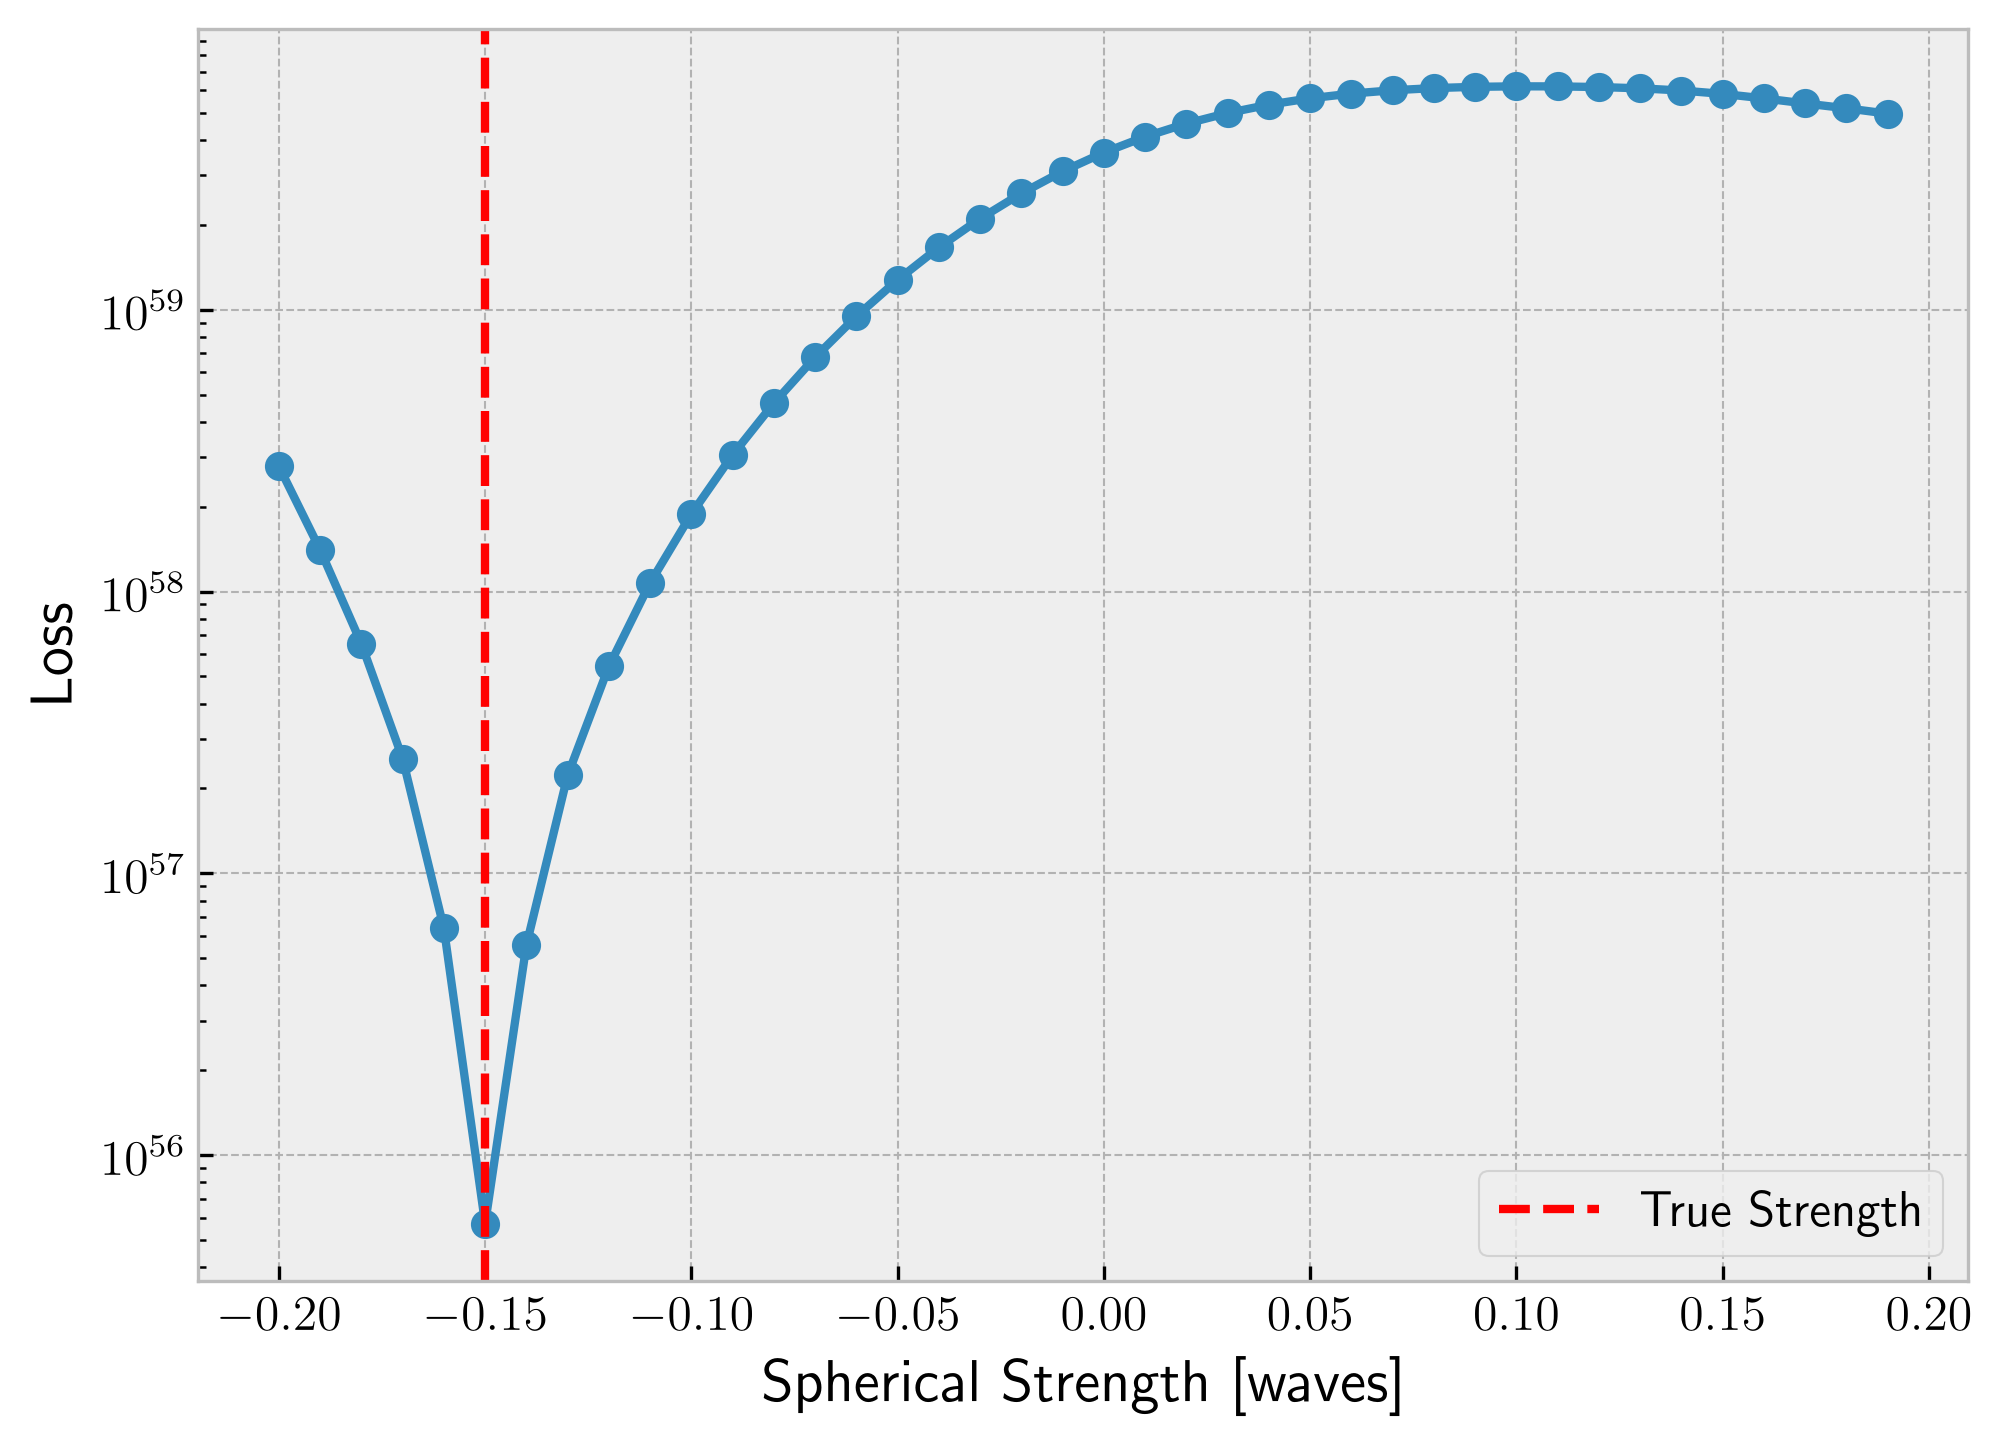

In [56]:
fig, ax = plt.subplots()
ax.plot(strengths, losses, marker = "o")
ax.set_yscale("log")
ax.set_xlabel("Spherical Strength [waves]")
ax.set_ylabel("Loss")
ax.axvline(-0.15, label = "True Strength", c = "red", ls = "dashed")
ax.legend()

In [57]:
estimated, info = reconstruction.optimize_aberration_3D(
    microscope=microscope,
    grid=grid,
    images=I,
    focal_z_levels=z_image_levels,
    sample_z_levels=z_sample_levels,
    modes=[[0, 4]],
    rho=1e48,
    diversities=diversities,
    initial_strengths=[0.0],
)

Iteration 0: loss=3.6110621039e+59, strengths (waves)=[0.]
Iteration 1: loss=1.8831565300e+58, strengths (waves)=[-0.1]
Iteration 2: loss=2.9414497171e+57, strengths (waves)=[-0.12721459]
Iteration 3: loss=2.2180481984e+56, strengths (waves)=[-0.14409758]
Iteration 4: loss=5.6650354081e+55, strengths (waves)=[-0.14960874]
Iteration 5: loss=5.6598448269e+55, strengths (waves)=[-0.14970817]
Stopped: Gradient and curvature tolerances satisfied.


In [ ]:
from IPython.display import HTML, display

aberration_animation, object_animation = plotting.animate_reconstruction(
    info=info,
    modes=estimated.modes,
    microscope=microscope,
    grid=grid,
    images=I,
    focal_z_levels=z_image_levels,
    sample_z_levels=z_sample_levels,
    rho=1e48,
    diversities=diversities,
    percentile=98,
    interval=500,
)

display(HTML(aberration_animation.to_jshtml()))
display(HTML(object_animation.to_jshtml()))

In [58]:
mask_3D = psf.random_bead_img_3D(grid = grid,
                                 z_levels = z_sample_levels,
                                 num_beads = 5,
                                 bead_size = 0.001)

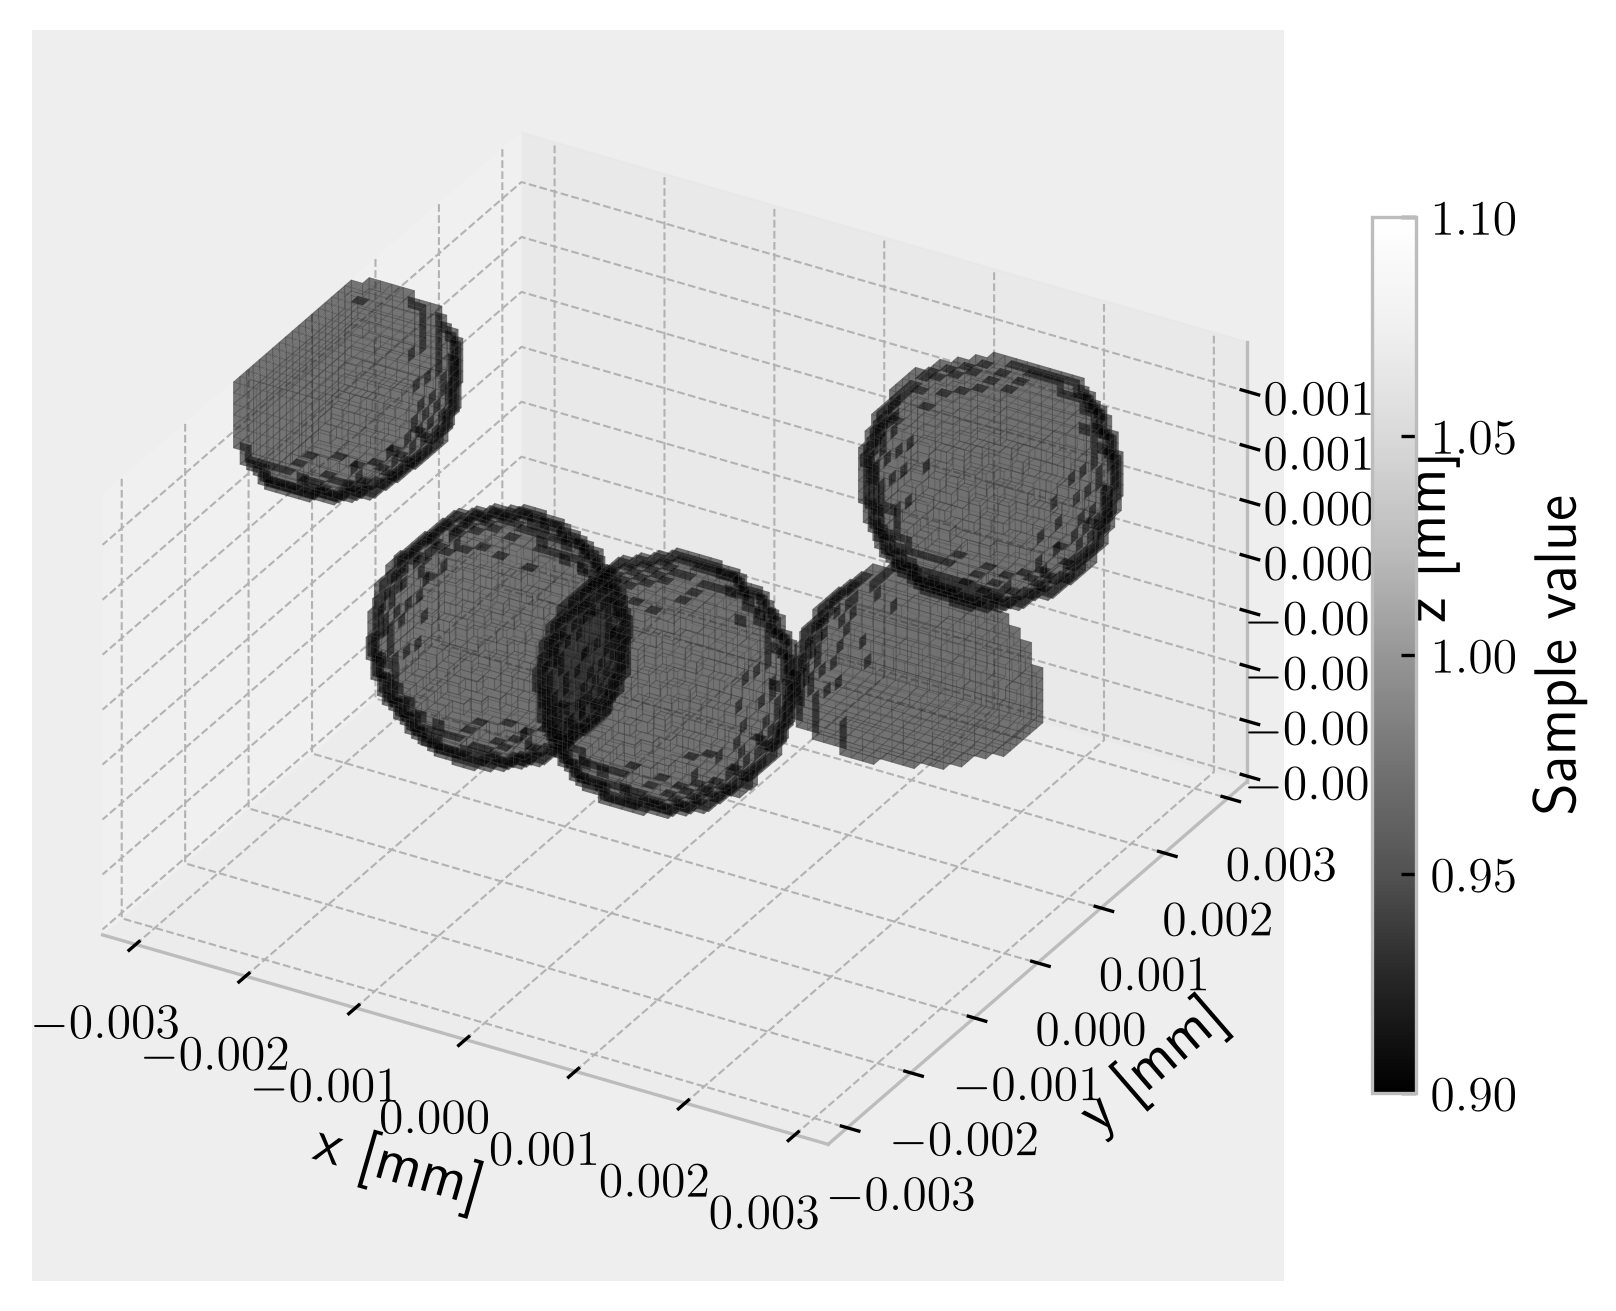

In [59]:
fig, ax = plotting.plot_sample_3D(mask_3D)

In [60]:
x, y, z, I = microscope.compute_image_3D(image = mask_3D,
                            aberration = aberration,
                            focal_z_levels = z_image_levels,
                            diversities = diversities)

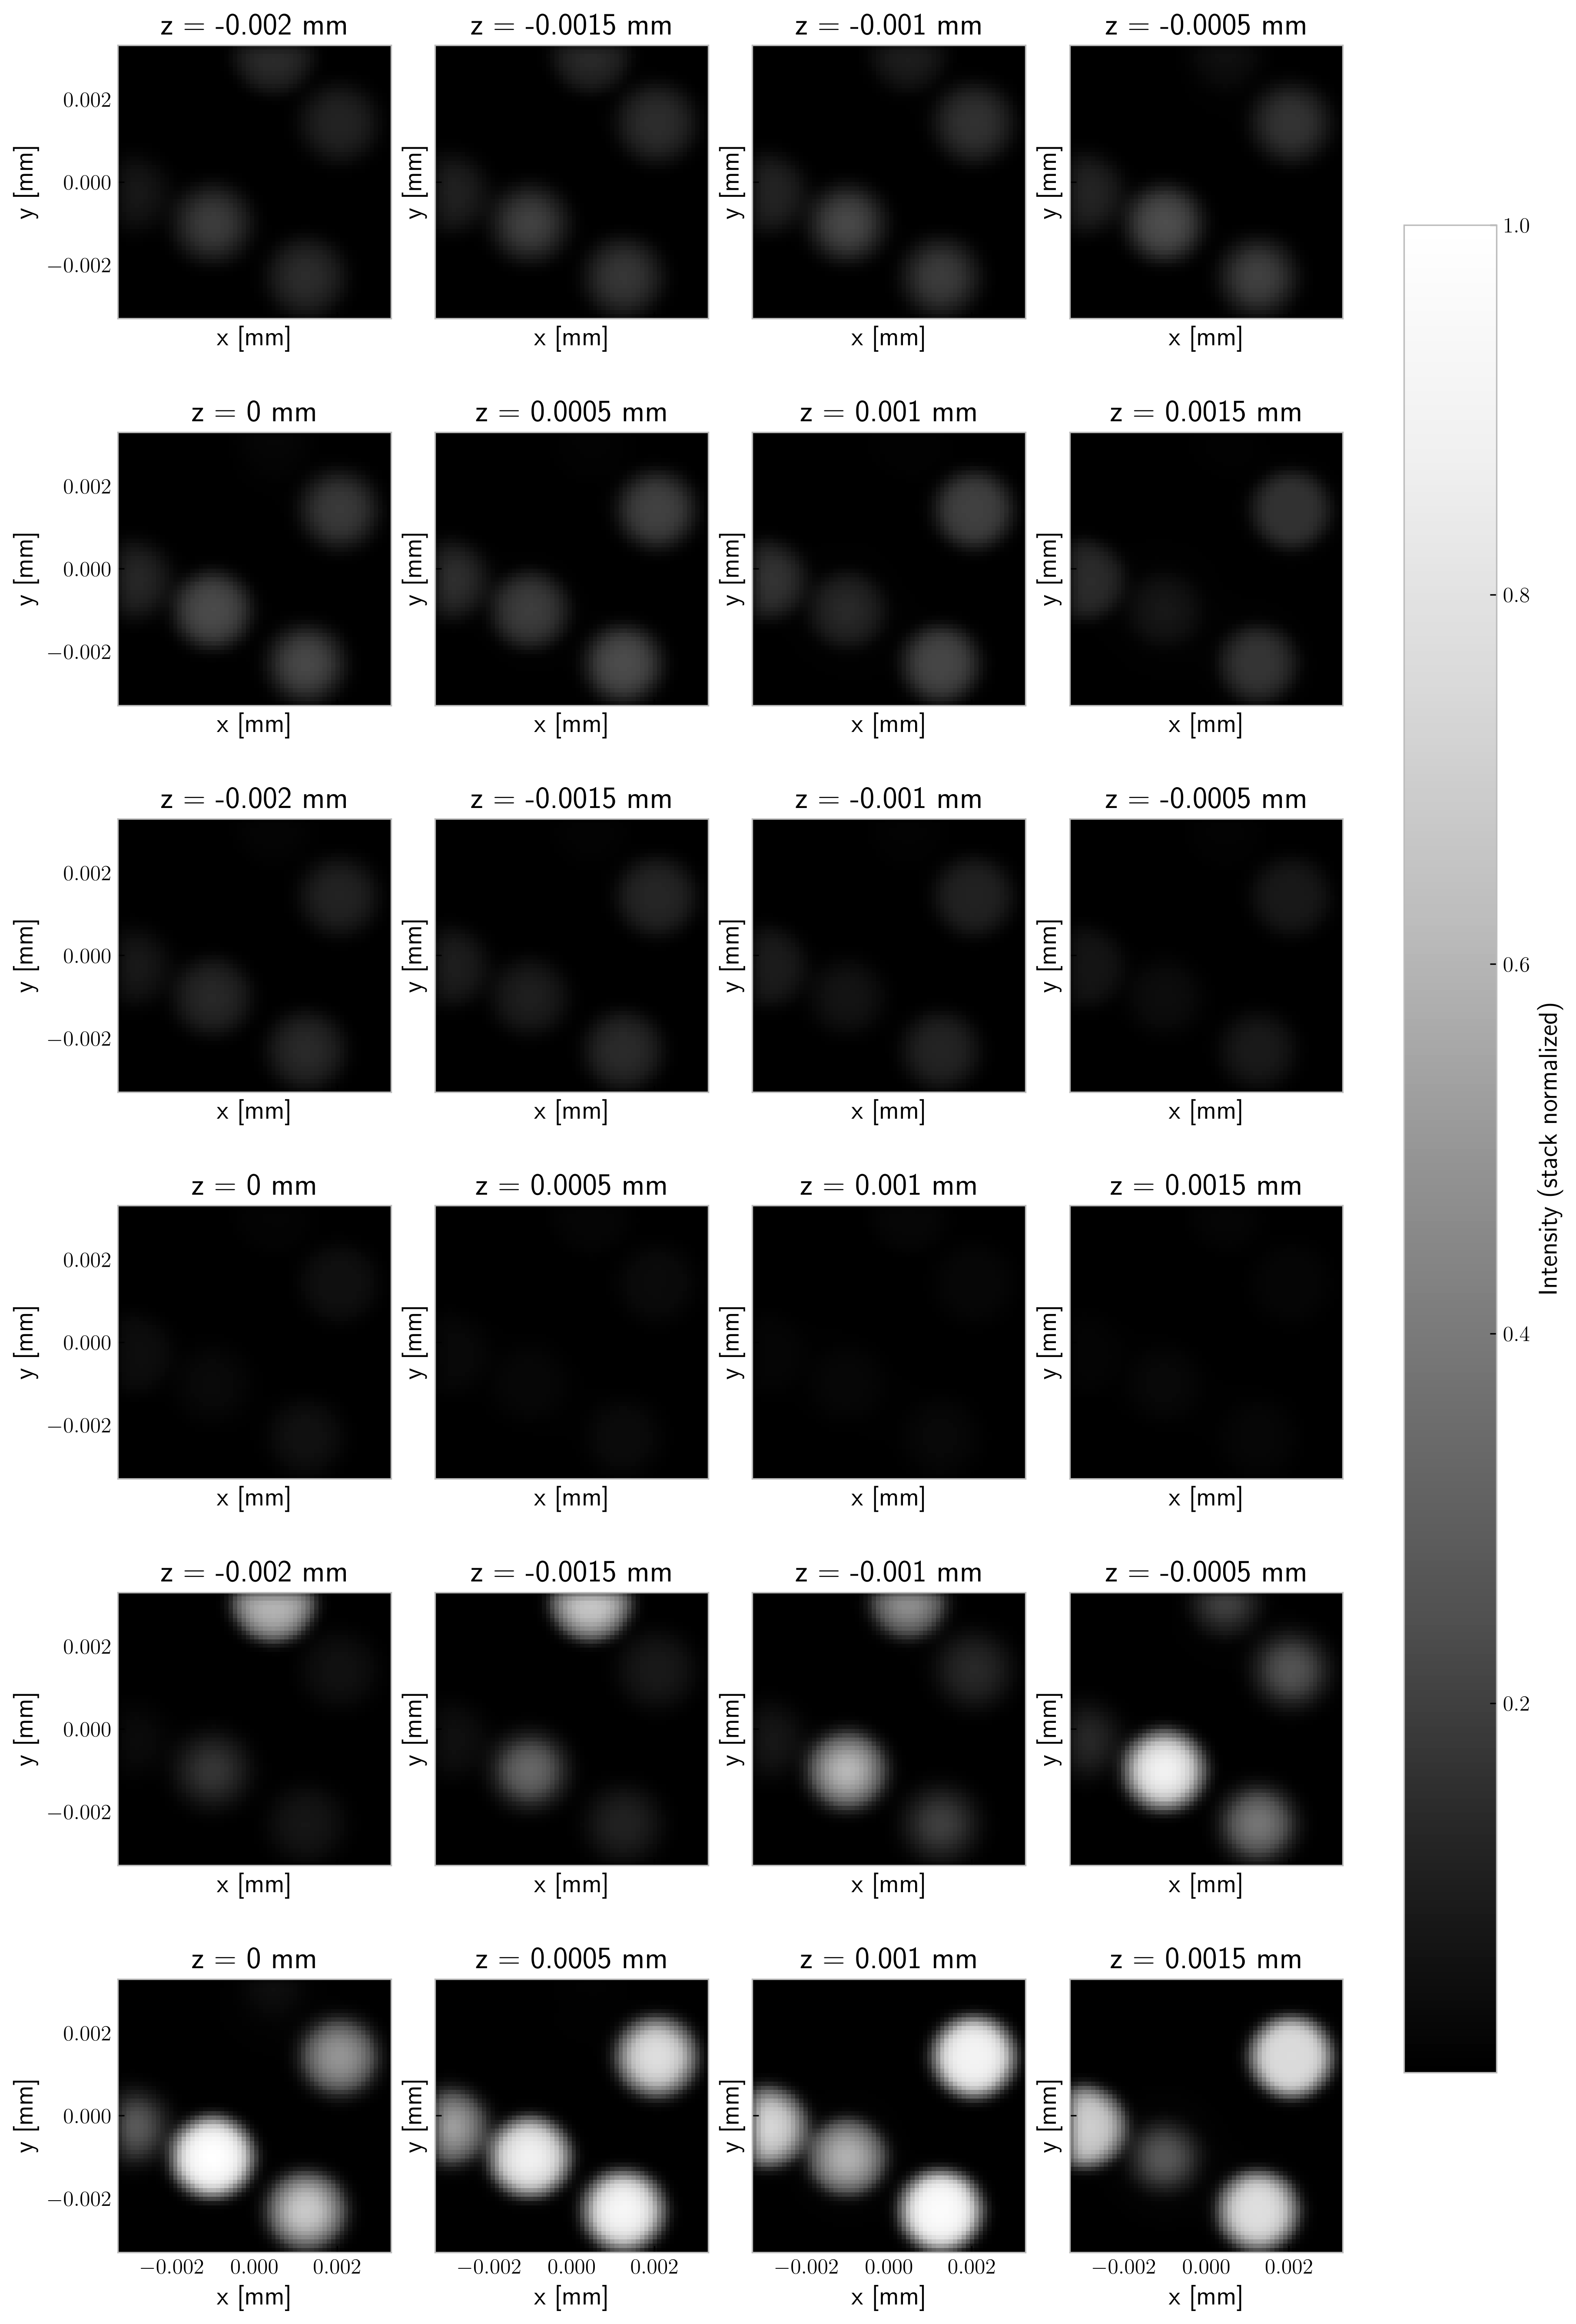

In [61]:
fig, axs = plotting.plot_image_stack(x, y, z, I, ncols=4)

In [62]:
reconstructed_img = reconstruction.estimate_sample_3D(microscope = microscope,
                                  grid = grid,
                                  images = I,
                                  focal_z_levels = z_image_levels,
                                  diversities = diversities,
                                  sample_z_levels = z_sample_levels,
                                  aberration = aberration,
                                  rho = 1e48)

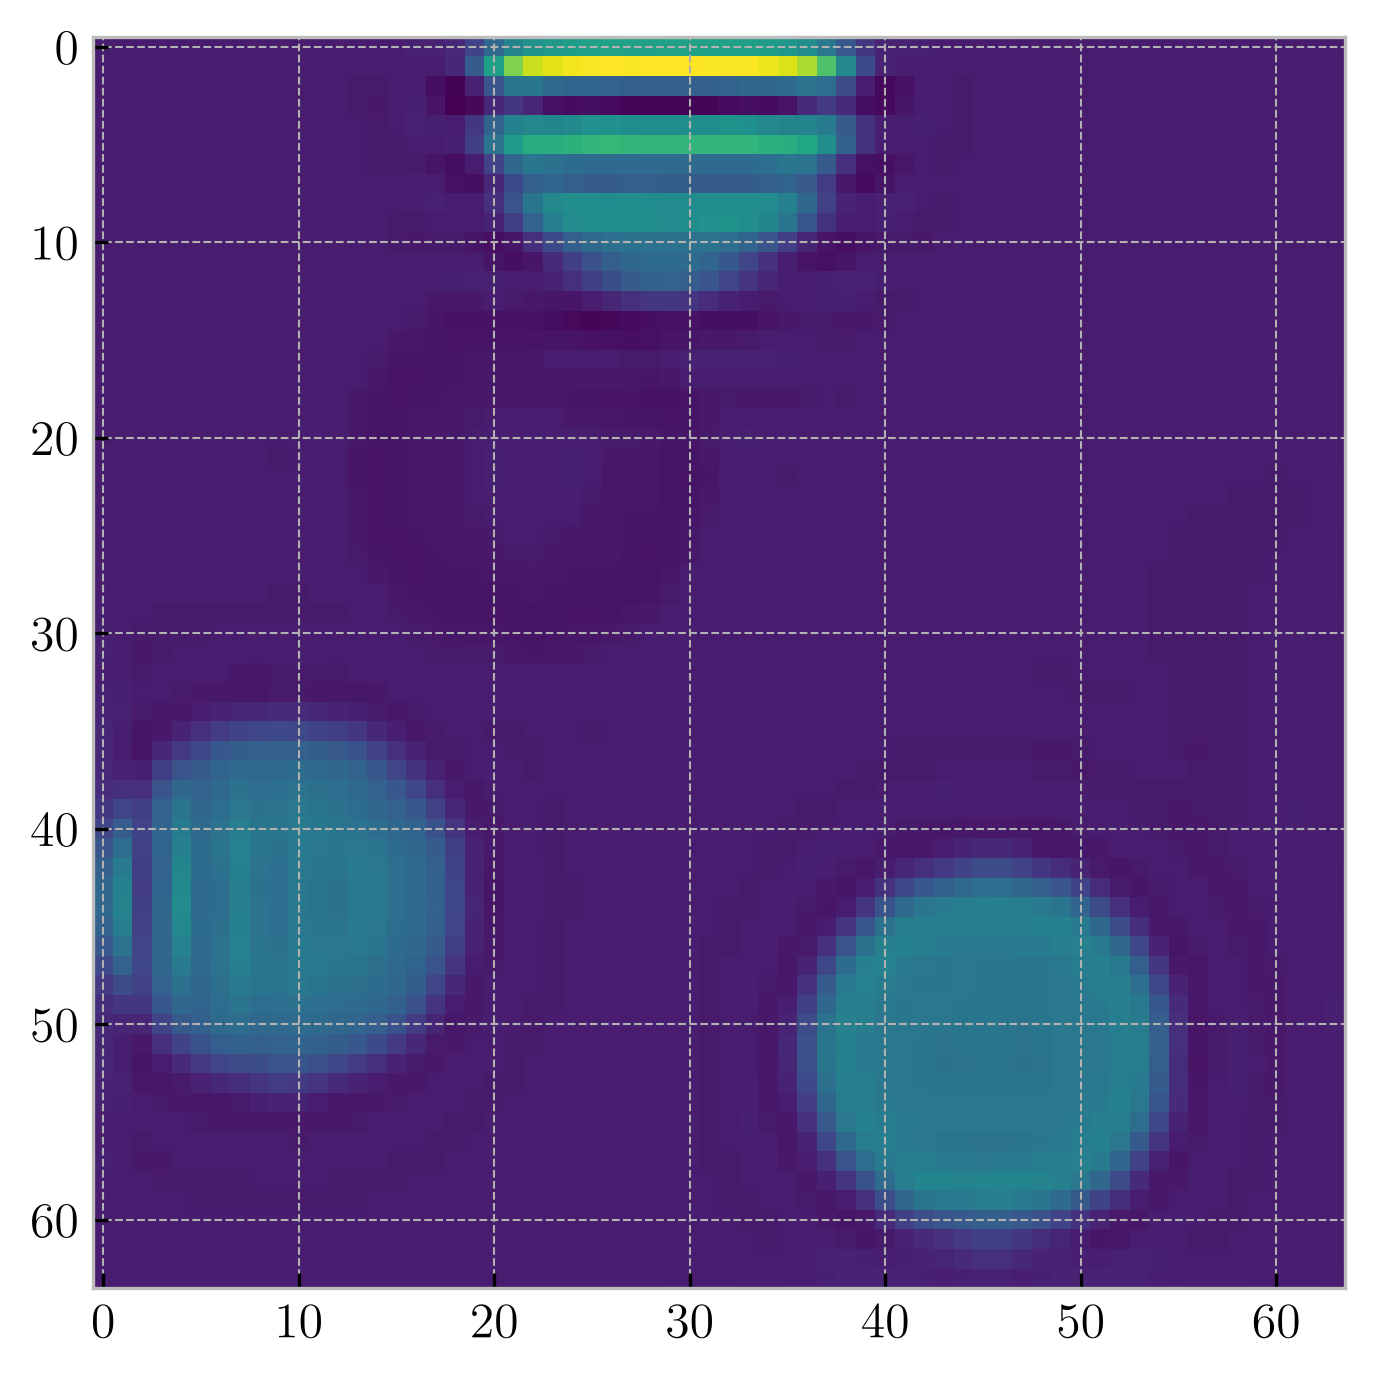

In [63]:
plt.imshow(reconstructed_img.image_mask[35])

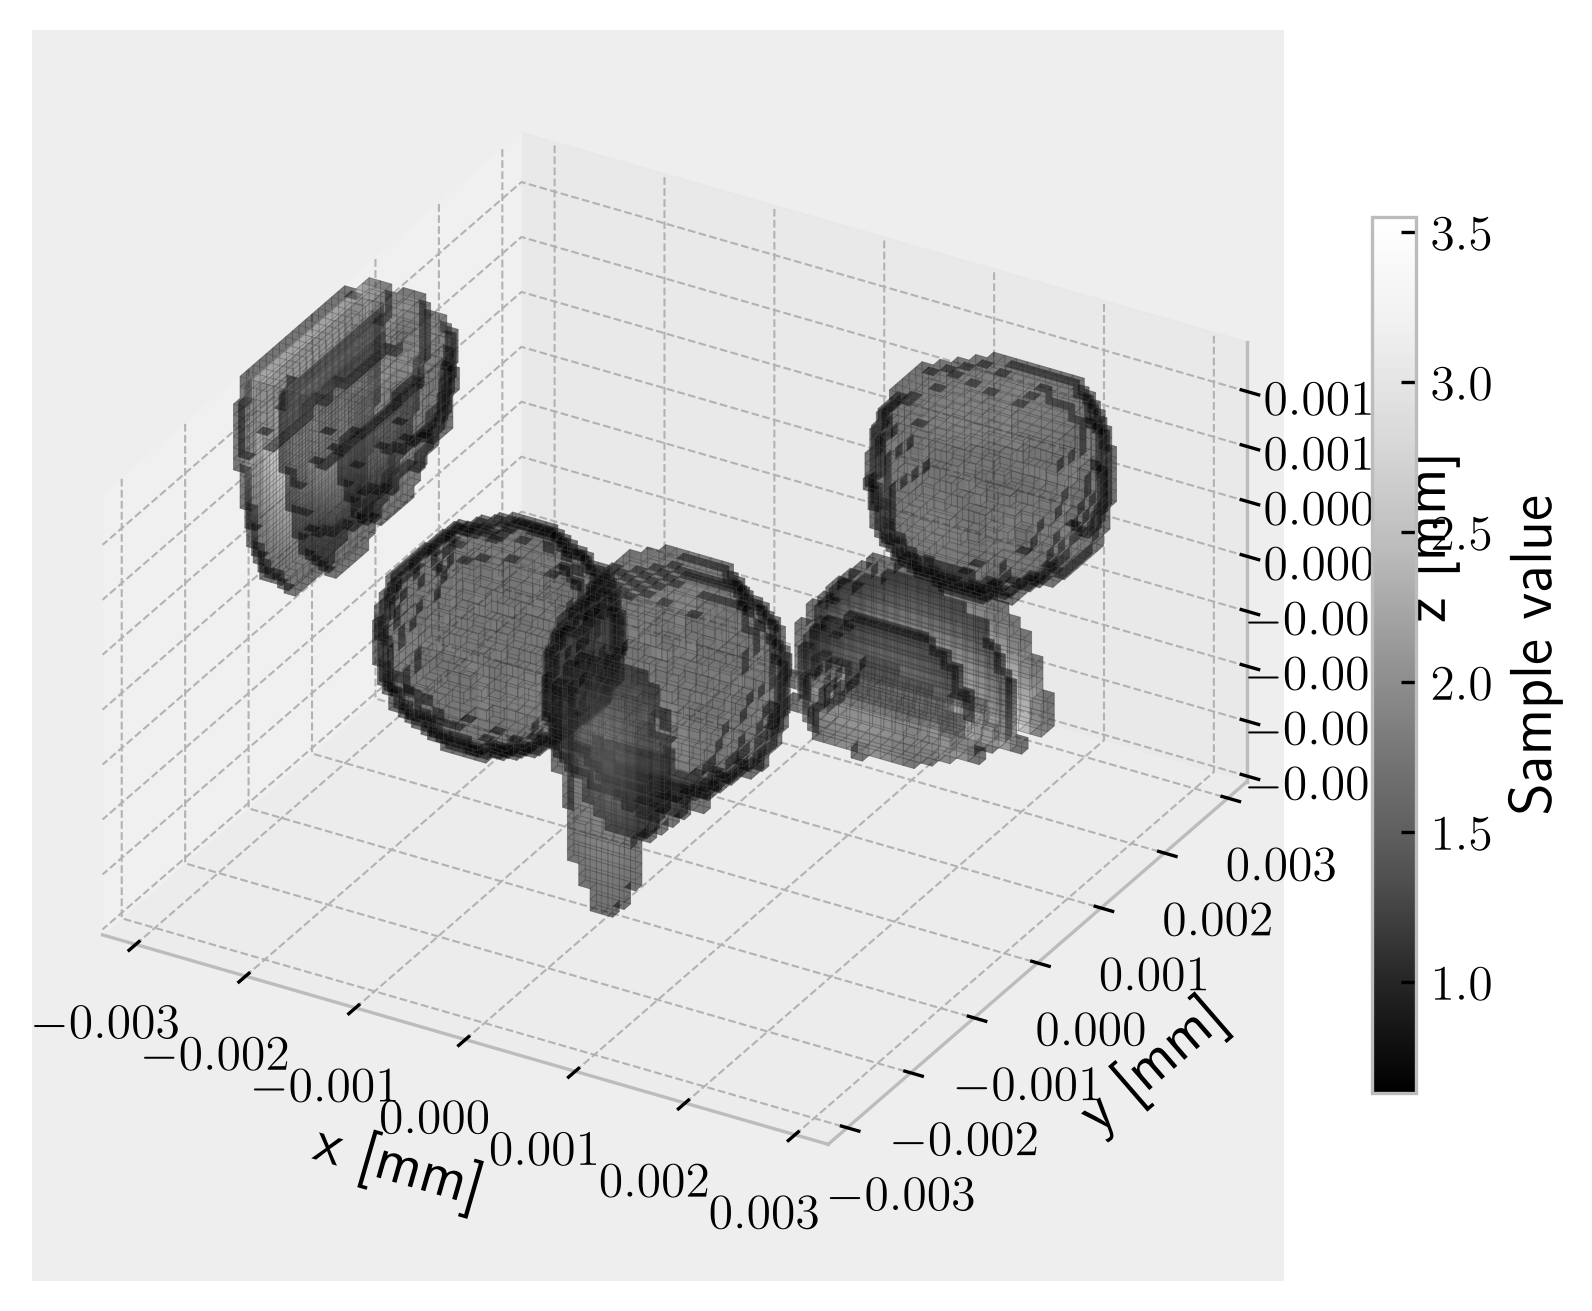

In [64]:
fig, ax = plotting.plot_sample_3D(reconstructed_img, np.percentile(reconstructed_img.image_mask,92))

In [65]:
strengths = np.arange(-0.20, 0.20, 0.01)
losses = np.zeros(len(strengths))
for i, strength in enumerate(strengths):
    losses[i] = reconstruction.evaluate_loss_3D(microscope = microscope, 
                                    grid = grid,
                                    images = I,
                                    focal_z_levels = z_image_levels,
                                    diversities = diversities,
                                    sample_z_levels = z_sample_levels,
                                    aberration = zernike.Aberration([[0,4]], [strength]),
                                    rho = 1e48)
    print(f"{strength}, {losses[i]}")

-0.2, 2.373419147937375e+59
-0.19, 1.188416746489274e+59
-0.18, 5.418705346785225e+58
-0.16999999999999998, 2.112562607987686e+58
-0.15999999999999998, 6.250573060314271e+57
-0.14999999999999997, 2.158347758011398e+57
-0.13999999999999996, 5.0018526355522775e+57
-0.12999999999999995, 1.3046614779611025e+58
-0.11999999999999994, 2.5910558748205644e+58
-0.10999999999999993, 4.416969255901104e+58
-0.09999999999999992, 6.914682793553713e+58
-0.08999999999999991, 1.0279079886559394e+59
-0.0799999999999999, 1.475750944275311e+59
-0.0699999999999999, 2.0633309113057123e+59
-0.05999999999999989, 2.819557800521402e+59
-0.04999999999999988, 3.769266112834723e+59
-0.03999999999999987, 4.927339141361011e+59
-0.02999999999999986, 6.2925121058625655e+59
-0.01999999999999985, 7.841981307952225e+59
-0.009999999999999842, 9.528033268871279e+59
1.6653345369377348e-16, 1.1278144732779682e+60
0.010000000000000175, 1.300063243591413e+60
0.020000000000000184, 1.4598247879302426e+60
0.030000000000000193, 1.5

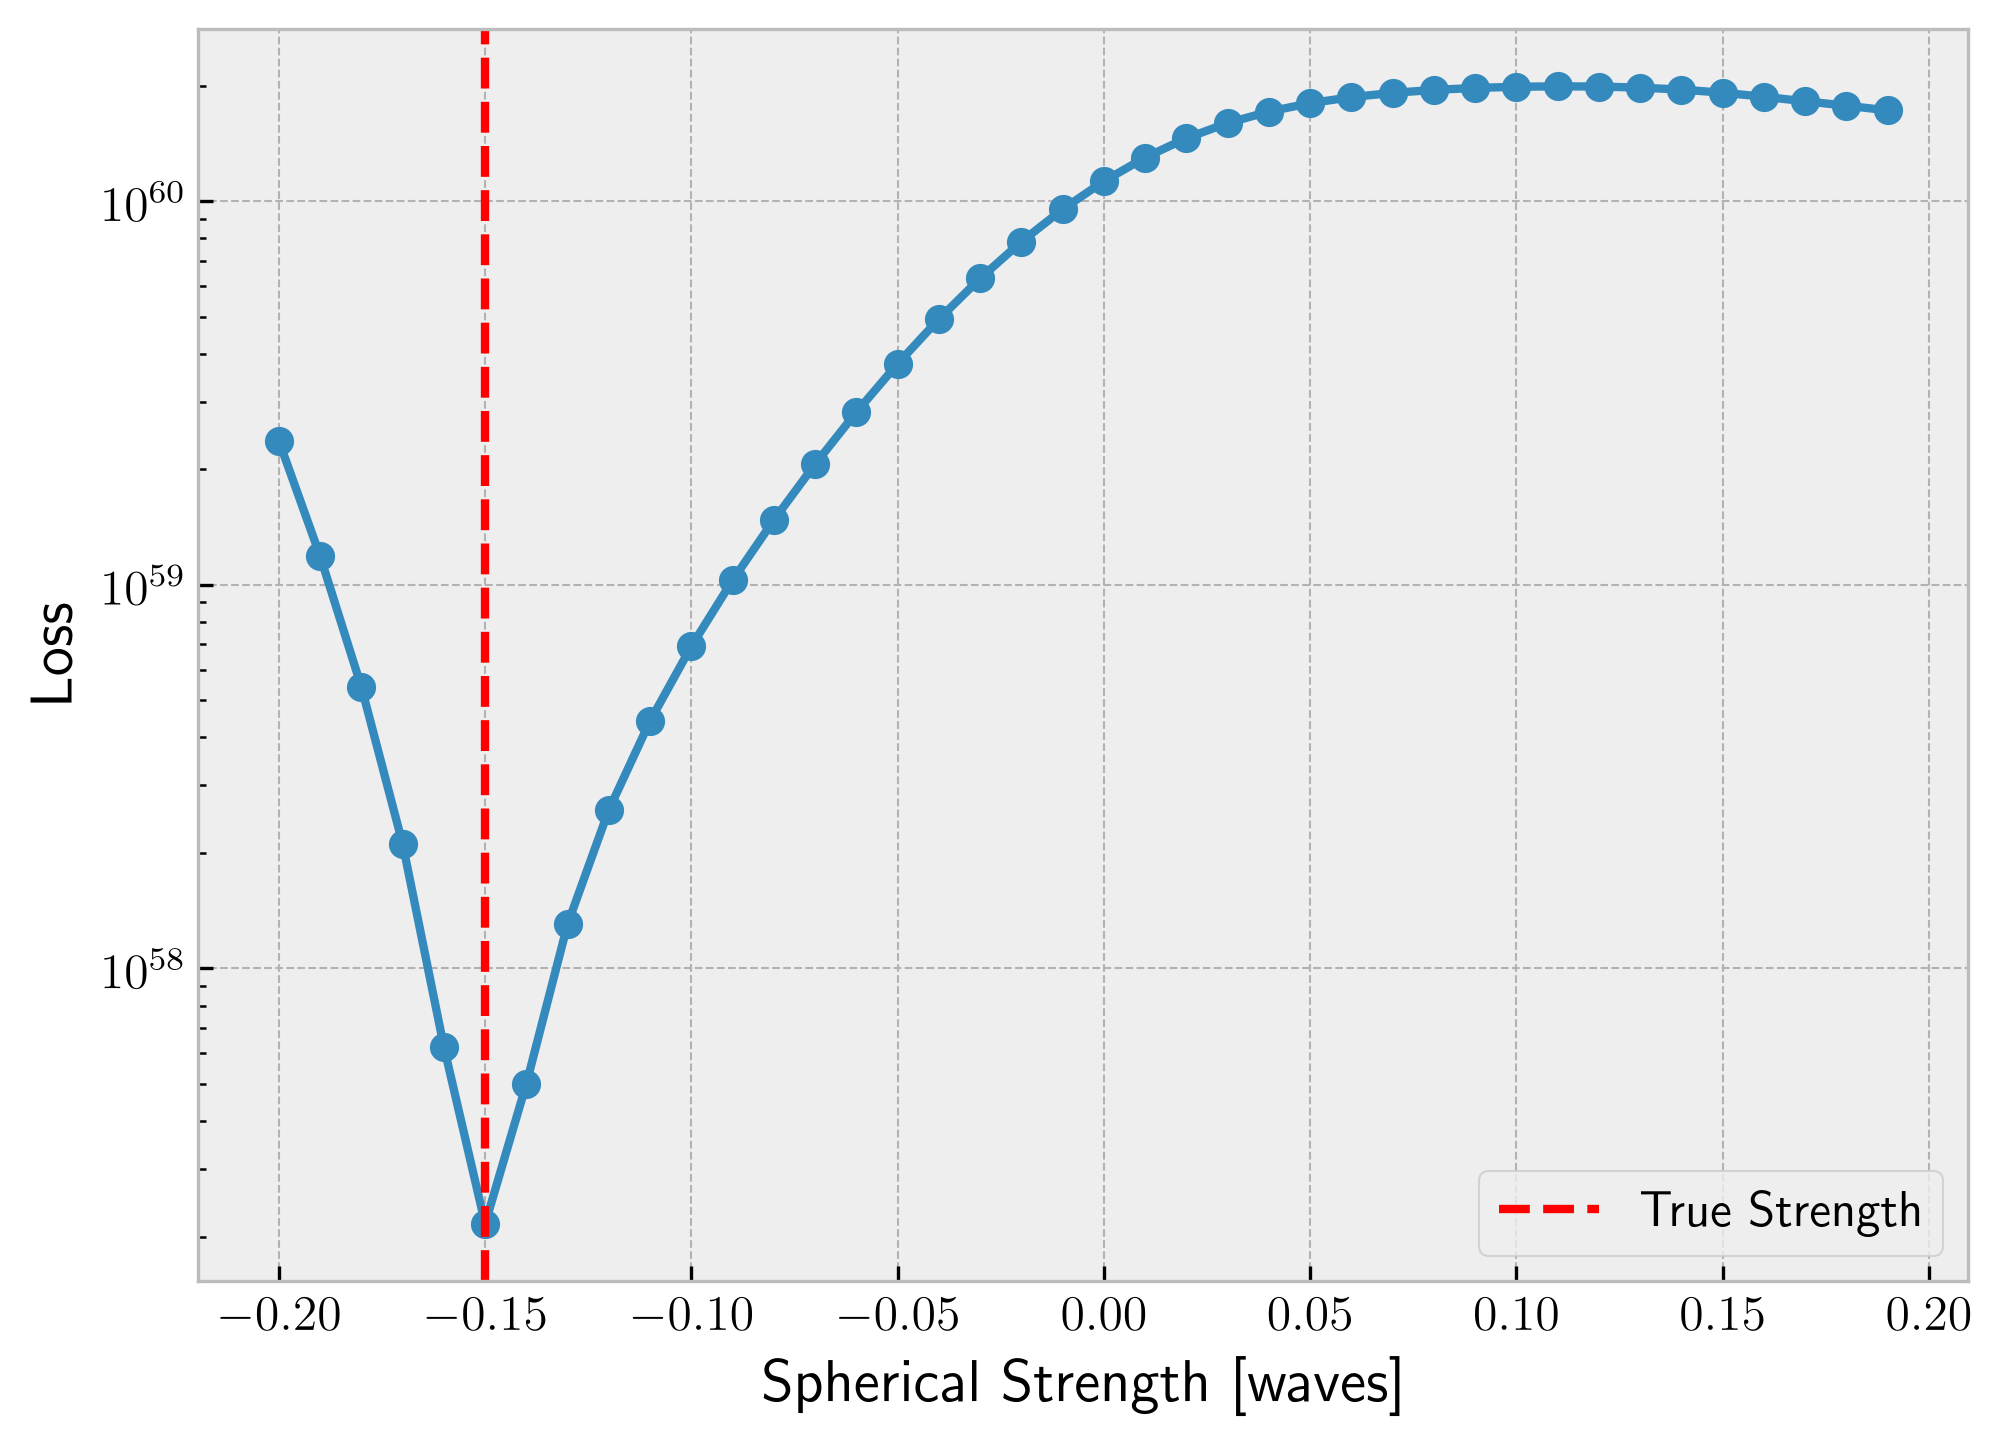

In [66]:
fig, ax = plt.subplots()
ax.plot(strengths, losses, marker = "o")
ax.set_yscale("log")
ax.set_xlabel("Spherical Strength [waves]")
ax.set_ylabel("Loss")
ax.axvline(-0.15, label = "True Strength", c = "red", ls = "dashed")
ax.legend()

In [67]:
estimated, info = reconstruction.optimize_aberration_3D(
    microscope=microscope,
    grid=grid,
    images=I,
    focal_z_levels=z_image_levels,
    sample_z_levels=z_sample_levels,
    modes=[[0, 4]],
    rho=1e48,
    diversities=diversities,
    initial_strengths=[0.0],
)

Iteration 0: loss=1.1278144733e+60, strengths (waves)=[0.]
Iteration 1: loss=6.9146827936e+58, strengths (waves)=[-0.1]
Iteration 2: loss=9.6322725264e+57, strengths (waves)=[-0.13356167]
Iteration 3: loss=2.3350867201e+57, strengths (waves)=[-0.1519952]
Iteration 4: loss=2.1559111585e+57, strengths (waves)=[-0.14981242]
Iteration 5: loss=2.1555794621e+57, strengths (waves)=[-0.14971312]
Iteration 6: loss=2.1555794610e+57, strengths (waves)=[-0.14971294]
Stopped: Gradient and curvature tolerances satisfied.


In [ ]:
from IPython.display import HTML, display

aberration_animation, object_animation = plotting.animate_reconstruction(
    info=info,
    modes=estimated.modes,
    microscope=microscope,
    grid=grid,
    images=I,
    focal_z_levels=z_image_levels,
    sample_z_levels=z_sample_levels,
    rho=1e48,
    diversities=diversities,
    percentile=98,
    interval=500,
)

display(HTML(aberration_animation.to_jshtml()))
display(HTML(object_animation.to_jshtml()))